# 02 — The Uzbekistan power-system landscape
## Структура генерации, активы и пространственная организация энергосистемы

---

### Purpose of this chapter / Назначение главы

**EN.** This chapter is the empirical scene-setter for the research paper. Before any
demand is forecast (NB06–07) or any investment signal is priced (NB08), the reader needs
a defensible answer to three questions: *what does Uzbekistan generate electricity from,
where do the generating assets physically sit, and how is that fleet changing over time?*
The chapter answers them in five movements — fuel mix → asset map → data cross-checks →
regional resource atlas → system context — and closes with the facts the downstream
models depend on.

**RU.** Эта глава — эмпирическое введение к исследовательской работе. Прежде чем
прогнозировать спрос (NB06–07) и оценивать инвестиционные сигналы (NB08), читателю нужен
обоснованный ответ на три вопроса: *из чего Узбекистан производит электроэнергию, где
физически расположены генерирующие активы и как меняется этот парк во времени?* Глава
отвечает на них в пять шагов — структура генерации → карта активов → перекрёстные проверки
данных → региональный атлас ресурсов → системный контекст — и завершается фактами, на
которые опираются последующие модели.

### Why a consultant reads this first / Почему консультант читает это первым

**EN.** Generation mix determines the *type* of advisory work that is in demand. A
gas-dominated system needs CCGT-efficiency and gas-supply-hedging advisory; a system with
a thin renewable share but a large pipeline needs grid-evacuation and balancing advisory;
an east-heavy demand centre paired with a west-heavy renewable build-out needs
transmission-corridor advisory. Each empirical finding below maps to a billable line of work.

**RU.** Структура генерации определяет, какие именно консалтинговые услуги востребованы.
Газовая система → повышение КПД ПГУ и хеджирование поставок газа; малая доля ВИЭ при
большом портфеле проектов → выдача мощности и балансировка; восточный центр спроса при
западном вводе ВИЭ → консалтинг по транзитным коридорам. Каждый эмпирический вывод ниже
соответствует конкретному направлению работ.

### Academic and data anchors / Научная и информационная база

- IEA (2022). *Uzbekistan Energy Profile* — fuel-mix taxonomy and security framing.
- IEA (2024). *Central Asia Energy Outlook* — peer-comparison benchmarks.
- IRENA (2024). *Renewable Capacity Statistics* — renewable-share methodology.
- CAREC (2024). *Renewable Energy Development in Uzbekistan* — oblast resource potential.
- Global Solar Atlas; IEA *Solar Roadmap for Uzbekistan* (2024) — irradiance and yield.
- Reference asset dataset (REF) — 46 named plants with per-asset source citations
  (`research/uzbekistan-energy/uzbekistan_energy_projects.json`).
- State Statistics Committee (StatSUZ) sector aggregates; World Bank power-plant GeoJSON.

> **Data convention.** Every figure carries a `Source:` line. "Electricity" is measured in
> TWh / GWh / MW. Figures and axis labels are in English; each part closes with a Russian
> *«Ключевые выводы»* box so the chapter reads in both languages without duplicating the plots.


## Part A — The generation fuel mix / Часть A — Структура генерации

**EN.** Part A establishes the macro picture from the project's unit-harmonised panel:
the current fuel split, its 1990→2024 trajectory, where Uzbekistan sits against its four
Central-Asian neighbours, and a capacity-factor sanity check on the data itself.

**RU.** Часть A задаёт макрокартину по гармонизированной по единицам панели проекта:
текущая структура генерации, её траектория 1990→2024, положение Узбекистана относительно
четырёх соседей по Центральной Азии и проверка качества данных через коэффициент
использования мощности.


### A.1 Setup / Настройка

**EN.** A single setup cell fixes the paths, the plotting defaults and three colour
palettes used through the chapter: a *fuel* palette for the mix section, a *technology*
palette (identical to the standalone research map, so notebook figures and the dashboard
stay visually consistent), and the status styling used by the asset maps.

**RU.** Один установочный блок фиксирует пути, параметры графиков и три цветовые палитры:
*топливную* — для раздела структуры генерации, *технологическую* (совпадает с интерактивной картой,
чтобы графики и дашборд были согласованы) и стилизацию статусов для карт активов.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, math
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Polygon, Circle
from matplotlib import animation
from IPython.display import IFrame, Image, HTML, display, Markdown

# ── paths (notebook runs from notebooks/, so repo root is '..') ──────────────
ROOT     = Path('..')
RESEARCH = ROOT / 'research' / 'uzbekistan-energy'
REF      = RESEARCH                                   # alias used by the v1 spatial cells
DATA     = ROOT / 'data' / 'processed'
CLEAN    = DATA / 'uzstat_clean'
RAW      = ROOT / 'data' / 'raw' / 'power plants (source - World Bank)'
OUT      = ROOT / 'outputs'; OUT.mkdir(exist_ok=True)

# ── plotting defaults ────────────────────────────────────────────────────────
plt.rcParams['figure.figsize']    = (11, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['font.size']         = 10

# ── fuel palette (fuel-mix section) ──────────────────────────────────────────
COLORS = {'gas':'#d97706','coal':'#374151','hydro':'#0891b2',
          'solar':'#facc15','wind':'#10b981','nuclear':'#6b21a8',
          'oil':'#7c2d12','renewables':'#16a34a','fossil':'#92400e'}

# ── technology palette (asset-level section; matches the research HTML map) ──
TECH = {
    'thermal':  {'color':'#b5612e', 'label':'Gas & thermal'},
    'hydro':    {'color':'#2c6e9e', 'label':'Hydropower'},
    'solar':    {'color':'#d99a1c', 'label':'Solar PV'},
    'wind':     {'color':'#1f8f7a', 'label':'Wind'},
    'nuclear':  {'color':'#7a4fb0', 'label':'Nuclear'},
    'storage':  {'color':'#4f7d52', 'label':'Storage (BESS)'},
    'gasfield': {'color':'#7d6a52', 'label':'Gas field'},
}
TECH_COLORS = {k: v['color'] for k, v in TECH.items()}
tech_colors = {'solar': TECH['solar']['color'],
               'wind':  TECH['wind']['color'],
               'hydro': TECH['hydro']['color']}
STATUS_EDGE  = {'op':'#222','build':'#444','plan':'#888'}
STATUS_LS    = {'op':'-','build':'--','plan':':'}
STATUS_ALPHA = {'op':0.85, 'build':0.55, 'plan':0.30}
techs = ['thermal','hydro','solar','wind','nuclear','storage','gasfield']
print('Setup complete — paths, palettes and imports unified for the merged chapter.')


Setup complete — paths, palettes and imports unified for the merged chapter.


### A.2 The generation record / Источник данных по генерации

**EN.** Two sources are combined because cross-country comparability is otherwise
impossible. `master_dataset_core.csv` is the project's unit-harmonised Uzbekistan panel
(built in `01_data_pipeline.ipynb`); only rows flagged `data_status == 'confirmed'` are
used, so no interpolated or preliminary value enters the headline figures.
`central_asia_panel.csv` (OWID/Ember + World Bank) supplies methodologically comparable
TWh-by-source for Kazakhstan, Kyrgyzstan, Tajikistan and Turkmenistan. The total is
*recomputed* from the fuel-level columns rather than trusted as a stored field — a first,
cheap data-integrity check.

**RU.** Объединяются два источника, иначе межстрановое сравнение невозможно.
`master_dataset_core.csv` — гармонизированная панель по Узбекистану (создана в
`01_data_pipeline.ipynb`); берутся только строки со `data_status == 'confirmed'`, поэтому
в итоговые цифры не попадают интерполированные или предварительные значения.
`central_asia_panel.csv` (OWID/Ember + Всемирный банк) даёт сопоставимые по методологии
данные по соседям. Итог *пересчитывается* из столбцов по источникам, а не берётся готовым —
это первая дешёвая проверка целостности данных.


In [2]:
master = pd.read_csv(DATA / 'master_dataset_core.csv')
master = master[master['data_status'] == 'confirmed'].copy()
master['year'] = master['year'].astype(int)
print('UZB master_dataset:', master.shape, 'years', master['year'].min(),'–', master['year'].max())

ca = pd.read_csv(CLEAN / 'central_asia_panel.csv')
ca['year'] = ca['year'].astype(int)
print('Central Asia panel:', ca.shape, ca['iso_code'].unique(),
      f'{ca["year"].min()}–{ca["year"].max()}')

# Define column mapping (master uses {fuel}_twh, CA uses {fuel}_electricity)
UZB_FUEL_COLS = {
    'gas':   'gen_gas_twh',
    'coal':  'gen_coal_twh',
    'hydro': 'gen_hydro_twh',
    'solar': 'gen_solar_twh',
    'wind':  'gen_wind_twh',
}
# Recompute total from the fuel-level data (master also stores gen_total_twh)
master['gen_total_twh_calc'] = master[list(UZB_FUEL_COLS.values())].sum(axis=1, min_count=1)
master.tail(5)[['year'] + list(UZB_FUEL_COLS.values()) + ['gen_total_twh_calc']]


UZB master_dataset: (34, 33) years 1990 – 2023
Central Asia panel: (330, 28) ['KAZ' 'KGZ' 'TJK' 'TKM' 'UZB'] 1960–2025


,year,gen_gas_twh,gen_coal_twh,gen_hydro_twh,gen_solar_twh,gen_wind_twh,gen_total_twh_calc
29,2019,52.561,3.816,6.461,0.000,0.015,62.853
30,2020,55.841,5.203,4.999,0.000,NaN,66.043
31,2021,60.057,4.955,4.972,0.049,0.001,70.034
32,2022,61.034,5.639,6.484,0.435,NaN,73.592
33,2023,56.384,8.271,6.940,0.622,0.007,72.224


### A.3 Headline — today's fuel mix / Текущая структура генерации

**EN.** One donut at the most recent confirmed year states the structural problem in a
single glance: dominance of one fuel is dominance of one supply risk. The centre label
reports the dominant-fuel share against the IEA "gas-dominated" threshold (>60%). For the
advisor this single number frames the entire engagement — a system this concentrated is
exposed to gas-price and gas-supply shocks that propagate straight to the retail tariff
through cross-subsidy.

**RU.** Одна кольцевая диаграмма за последний подтверждённый год сразу показывает
структурную проблему: доминирование одного топлива = доминирование одного риска поставок.
Подпись в центре сравнивает долю доминирующего топлива с порогом IEA «газовая система»
(>60%). Для консультанта это число задаёт рамку всего проекта: настолько
концентрированная система уязвима к ценовым и поставочным шокам по газу, которые через
перекрёстное субсидирование напрямую доходят до розничного тарифа.


Year 2023: total generation = 72.2 TWh


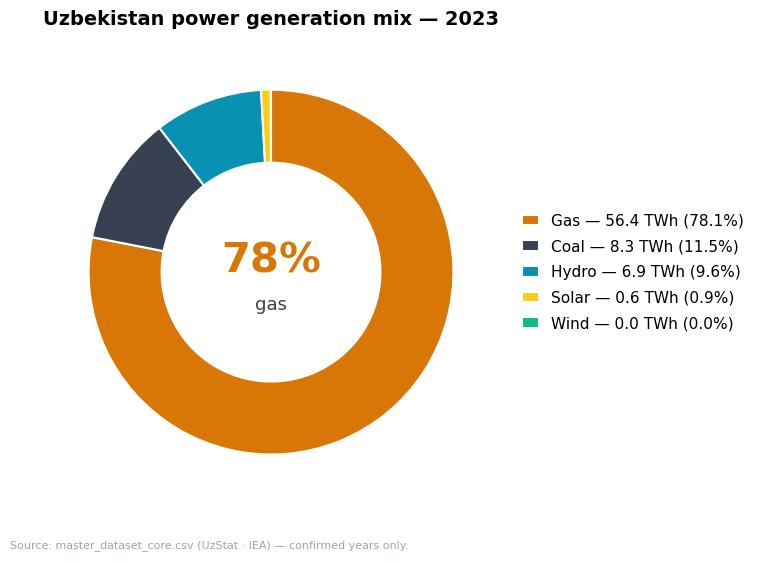


Gas dominance interpretation:
  Gas share = 78.1% → IEA threshold for "gas-dominated" is >60%.


In [3]:
year_anchor = master['year'].max()
row = master[master['year']==year_anchor].iloc[0]
mix = {k: row[c] for k, c in UZB_FUEL_COLS.items() if pd.notna(row[c]) and row[c] > 0}
total = sum(mix.values())
print(f'Year {year_anchor}: total generation = {total:.1f} TWh')

order = sorted(mix, key=mix.get, reverse=True)
vals  = [mix[k] for k in order]
share = {k: mix[k] / total * 100 for k in order}
dominant = order[0]

fig, ax = plt.subplots(figsize=(9, 6))
wedges, _ = ax.pie(
    vals, colors=[COLORS[k] for k in order],
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.40, edgecolor='white', linewidth=1.5))
ax.set_aspect('equal')

# Bold centre label states the single-fuel dominance at a glance.
ax.text(0, 0.06, f'{share[dominant]:.0f}%', ha='center', va='center',
        fontsize=30, fontweight='bold', color=COLORS[dominant])
ax.text(0, -0.18, dominant, ha='center', va='center', fontsize=13, color='#374151')

# Labels sit in a largest-first side legend, so the near-zero slices
# (solar, wind) never overlap the way per-wedge labels did.
legend_labels = [f'{k.capitalize()} — {mix[k]:.1f} TWh ({share[k]:.1f}%)' for k in order]
ax.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1.02, 0.5),
          frameon=False, fontsize=11, handlelength=1.1, labelspacing=0.7)

ax.set_title(f'Uzbekistan power generation mix — {year_anchor}',
             fontsize=14, fontweight='bold', loc='left', pad=14)
fig.text(0.04, 0.02,
         'Source: master_dataset_core.csv (UzStat · IEA) — confirmed years only.',
         fontsize=8, color='#9ca3af')
fig.subplots_adjust(left=0.04, right=0.62, top=0.86, bottom=0.10)
plt.show()
print('\nGas dominance interpretation:')
print(f'  Gas share = {share.get("gas",0):.1f}% → IEA threshold for "gas-dominated" is >60%.')


### A.4 Evolution 1990 → 2024 / Эволюция 1990 → 2024

**EN.** A stacked area shows two things at once: absolute generation growth and the shift
in composition. The companion table reports compound annual growth (CAGR) over two windows
— the full confirmed record and a recent (post-2010) window — computed per fuel from the
first year that fuel is actually switched on. This is the corrected version of the metric:
the earlier table demanded the exact endpoint years be present and so returned an empty
recent column on a panel that ends in 2023.

**RU.** Диаграмма с областями (stacked area) показывает одновременно рост абсолютной выработки и изменение структуры.
Сопроводительная таблица даёт среднегодовой темп роста (CAGR) по двум окнам — за весь
подтверждённый период и за недавнее (после 2010) окно — рассчитанный по каждому источнику с
первого года его фактического появления. Это исправленная версия метрики: прежняя таблица
требовала наличия точных граничных лет и потому возвращала пустой недавний столбец на
панели, которая заканчивается 2023 годом.

$$
\text{Share}_{f,t}=\frac{G_{f,t}}{\sum_{f'} G_{f',t}},\qquad
\text{CAGR}_f^{[t_0,t_1]}=\left(\frac{G_{f,t_1}}{G_{f,t_0}}\right)^{1/(t_1-t_0)}-1 .
$$


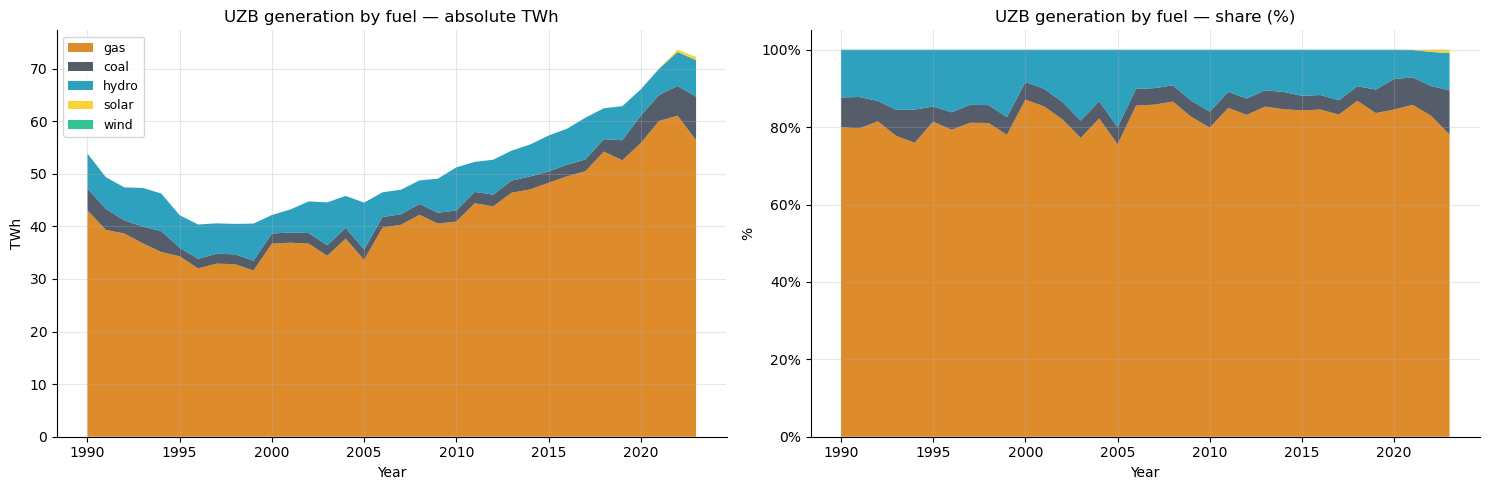

Compound annual growth rate by fuel (confirmed panel 1990-2023):
 fuel  first_yr  last_yr  CAGR_full_%  CAGR_2010_2023_%
  gas      1990     2023         0.82              2.50
 coal      1990     2023         2.11             11.04
hydro      1990     2023         0.13             -1.27
solar      2021     2023       256.28            256.28
 wind      2019     2023       -17.35            -17.35

Reading: gas drove the absolute build-out; hydro is flat (no new large dams);
solar/wind show high CAGRs off a near-zero 2019 base — large % on a small level.


In [4]:
hist = master.dropna(subset=['gen_total_twh_calc']).copy()
years = hist['year'].values
fuels = list(UZB_FUEL_COLS.keys())
mat = np.vstack([hist[UZB_FUEL_COLS[f]].fillna(0).values for f in fuels])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.stackplot(years, mat, labels=fuels, colors=[COLORS[f] for f in fuels], alpha=0.85)
ax.set_title('UZB generation by fuel — absolute TWh')
ax.set_xlabel('Year'); ax.set_ylabel('TWh'); ax.grid(alpha=.3)
ax.legend(loc='upper left', fontsize=9)

ax = axes[1]
mat_share = mat / mat.sum(axis=0, keepdims=True) * 100
ax.stackplot(years, mat_share, labels=fuels, colors=[COLORS[f] for f in fuels], alpha=0.85)
ax.set_title('UZB generation by fuel — share (%)')
ax.set_xlabel('Year'); ax.set_ylabel('%'); ax.grid(alpha=.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
plt.tight_layout(); plt.savefig(DATA/'eda_energy_mix_evolution.png', dpi=140); plt.show()

# ── CAGR table (robust to a panel that ends in 2023 and to fuels that
#    only switch on mid-series, e.g. solar/wind after 2018) ──────────────────
y_first, y_last = int(hist['year'].min()), int(hist['year'].max())
MID = 2010  # split the record into a long-run and a recent window

def _cagr(col, a, b):
    s = hist.set_index('year')[col]
    if a not in s.index or b not in s.index: return np.nan
    va, vb = s.loc[a], s.loc[b]
    if not (va and vb) or va <= 0 or vb <= 0 or b <= a: return np.nan
    return (vb / va) ** (1 / (b - a)) - 1

rows = []
for f, col in UZB_FUEL_COLS.items():
    nz = hist.loc[hist[col].fillna(0) > 0, 'year']           # years the fuel is actually on
    if len(nz) < 2:
        rows.append({'fuel': f, 'first_yr': '—', 'last_yr': '—',
                     'CAGR_full_%': np.nan, f'CAGR_{MID}_{y_last}_%': np.nan}); continue
    a, b = int(nz.min()), int(nz.max())
    full = _cagr(col, a, b)
    rec  = _cagr(col, max(a, MID), b)
    rows.append({'fuel': f, 'first_yr': a, 'last_yr': b,
                 'CAGR_full_%':  round(full * 100, 2) if full == full else np.nan,
                 f'CAGR_{MID}_{y_last}_%': round(rec * 100, 2) if rec == rec else np.nan})
cagr_tab = pd.DataFrame(rows)
print(f'Compound annual growth rate by fuel (confirmed panel {y_first}-{y_last}):')
print(cagr_tab.to_string(index=False))
print('\nReading: gas drove the absolute build-out; hydro is flat (no new large dams);')
print('solar/wind show high CAGRs off a near-zero 2019 base — large % on a small level.')


**Interpretation / Интерпретация.**

**EN.** Gas is structural, not incidental: it carries the bulk of both the level and the
1990→2024 increment, so demand growth has historically been met by burning more gas rather
than by diversifying. Hydro is effectively flat after 2010 — there are no new large dams,
only turbine modernisation — which means any renewable-share gain must come from solar and
wind, not water. Solar and wind post enormous percentage CAGRs, but off a near-zero 2019
base; in *level* terms they are still a thin slice. The advisory implication is direct: the
transition is a *new-build* story (solar/wind/storage), not a re-dispatch of existing assets.

**RU.** Газ структурен, а не случаен: на него приходится основная часть и уровня, и прироста
1990→2024 — рост спроса исторически покрывался сжиганием большего объёма газа, а не
диверсификацией. Гидро после 2010 практически не растёт (новых крупных ГЭС нет, только
модернизация турбин), значит, любой прирост доли ВИЭ должен идти от солнца и ветра, а не от
воды. Солнце и ветер показывают огромные процентные CAGR, но от почти нулевой базы 2019 года;
в *абсолютном выражении* это всё ещё тонкий слой. Вывод для консультанта прямой: переход — это история
*нового строительства* (солнце/ветер/накопители), а не перераспределения существующих активов.


### A.4b The latest year — 2024 / Последний год — 2024

**EN.** The donut (§A.3) and the evolution stack (§A.4) close on the last *confirmed* year, 2023, because the headline figures deliberately exclude preliminary rows. The most recent year on record, however, is 2024, and it matters: total generation jumped to **≈ 82.0 TWh** (StatSUZ preliminary), about **+10 %** in a single year — the largest annual step in the series. The fuel-level split for 2024 (gas / coal / hydro) is not yet published by the IEA, so the thermal-plus-hydro mass is shown here as one labelled block rather than fabricated into shares; what *is* firmly reported is the renewable surge: solar output rose **6.4×** (0.62 → 3.97 TWh) and wind **≈ 110×** (0.007 → 0.79 TWh) year-on-year, lifting non-hydro renewables from a rounding error to **≈ 5.8 %** of generation. Installed capacity reached ≈ 21.5 GW.

**RU.** Кольцевая диаграмма (§A.3) и эволюционный стек (§A.4) заканчиваются на последнем *подтверждённом* годе, 2023, поскольку итоговые цифры намеренно исключают предварительные строки. Однако самый свежий год в данных — 2024, и он важен: суммарная выработка выросла до **≈ 82,0 ТВт·ч** (предварительно, Агентство статистики), примерно **+10 %** за один год — наибольший годовой шаг в ряду. Разбивка по топливу за 2024 (газ / уголь / гидро) ещё не опубликована МЭА, поэтому тепловая и гидрогенерация показаны единым подписанным блоком, а не разложены на доли путём допущений; что твёрдо зафиксировано — это рост ВИЭ: выработка солнца выросла в **6,4 раза** (0,62 → 3,97 ТВт·ч), ветра — в **≈ 110 раз** (0,007 → 0,79 ТВт·ч) год к году, подняв невгидровые ВИЭ с погрешности округления до **≈ 5,8 %** генерации. Установленная мощность достигла ≈ 21,5 ГВт.

*Academic anchor:* IRENA (2024), *Renewable Capacity Statistics*; IEA (2024), *Central Asia Energy Outlook*.


In [ ]:
OUT = Path('../outputs'); OUT.mkdir(parents=True, exist_ok=True)

# Unfiltered core reaches 2024 (preliminary); solar/wind from the StatSUZ national series.
core_full = pd.read_csv(DATA/'master_dataset_core.csv'); core_full['year'] = core_full['year'].astype(int)
nat       = pd.read_csv(CLEAN/'uzb_energy_national.csv'); nat['year']       = nat['year'].astype(int)

def _g(y, col):
    s = core_full.loc[core_full['year']==y, col]
    return float(s.iat[0]) if len(s) and pd.notna(s.iat[0]) else 0.0
def _n(y, col):
    s = nat.loc[nat['year']==y, col]
    return float(s.iat[0])/1000 if len(s) and pd.notna(s.iat[0]) else 0.0   # mln kWh -> TWh

yrs   = [2022, 2023, 2024]
tot   = {2022:_g(2022,'gen_total_twh'), 2023:_g(2023,'gen_total_twh'),
         2024:_g(2024,'gen_total_twh_bridged')}
sol   = {y:_n(y,'solar_output_mln_kwh') for y in yrs}
wnd   = {y:_n(y,'wind_output_mln_kwh')  for y in yrs}
resid = {y: tot[y] - sol[y] - wnd[y] for y in yrs}   # thermal + hydro (2024 split pending IEA)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={'width_ratios':[1.05, 1.25]})

# (A) total generation 2022-2024 with renewables split out from the thermal+hydro mass
ax = axes[0]
x = np.arange(len(yrs))
b_res = [resid[y] for y in yrs]; b_sol = [sol[y] for y in yrs]; b_wnd = [wnd[y] for y in yrs]
ax.bar(x, b_res, color='#9ca3af', hatch='//', edgecolor='white',
       label='Thermal + hydro (2024 split pending IEA)')
ax.bar(x, b_sol, bottom=b_res, color=COLORS['solar'], label='Solar')
ax.bar(x, b_wnd, bottom=np.add(b_res, b_sol), color=COLORS['wind'], label='Wind')
for i, y in enumerate(yrs):
    ax.text(i, tot[y]+0.8, f'{tot[y]:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([str(y) for y in yrs])
ax.set_ylabel('TWh'); ax.set_ylim(0, max(tot.values())*1.12)
ax.set_title('Generation by year — renewables split out', fontsize=12, fontweight='bold', loc='left')
ax.legend(fontsize=8, loc='lower center', ncol=1, framealpha=.9)

# (B) the non-hydro renewable surge, 2018-2024 (StatSUZ national output series)
ax = axes[1]
sy = list(range(2018, 2025))
ss = [_n(y,'solar_output_mln_kwh') for y in sy]
ws = [_n(y,'wind_output_mln_kwh')  for y in sy]
w  = 0.4; xs = np.arange(len(sy))
ax.bar(xs-w/2, ss, w, color=COLORS['solar'], label='Solar')
ax.bar(xs+w/2, ws, w, color=COLORS['wind'],  label='Wind')
ax.annotate('×6.4 vs 2023', (len(sy)-1-w/2, ss[-1]), textcoords='offset points',
            xytext=(-4, 6), fontsize=8, ha='center', color='#a16207', fontweight='bold')
ax.annotate('×110 vs 2023', (len(sy)-1+w/2, ws[-1]), textcoords='offset points',
            xytext=(10, 6), fontsize=8, ha='center', color='#047857', fontweight='bold')
ax.set_xticks(xs); ax.set_xticklabels([str(y) for y in sy])
ax.set_ylabel('TWh'); ax.set_title('Non-hydro renewable output 2018–2024', fontsize=12, fontweight='bold', loc='left')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=.3, axis='y')

fig.text(0.99, -0.03,
         'Source: master_dataset_core.csv (2024 total = StatSUZ preliminary, fuel split pending IEA); '
         'solar/wind output from UzStat national series (uzb_energy_national.csv).',
         ha='right', fontsize=7, color='#6b7280')
plt.tight_layout(); plt.savefig(OUT/'02_generation_2024.png', dpi=140, bbox_inches='tight'); plt.show()

print(f'2024 generation (StatSUZ preliminary): total {tot[2024]:.1f} TWh '
      f'(+{(tot[2024]/tot[2023]-1)*100:.0f}% vs 2023); thermal+hydro {resid[2024]:.1f} (split pending), '
      f'solar {sol[2024]:.2f}, wind {wnd[2024]:.2f}.')
print(f'Non-hydro RE share of generation: 2023 {(sol[2023]+wnd[2023])/tot[2023]*100:.1f}% -> '
      f'2024 {(sol[2024]+wnd[2024])/tot[2024]*100:.1f}%.')


### A.5 Peer benchmark — Uzbekistan vs Central Asia / Сравнение с соседями

**EN.** The same indicator (renewable share of generation, %) is plotted for all five
Central-Asian systems. The story for the advisor is that "Central Asia" is not one market:
Kyrgyzstan and Tajikistan are hydro-dominated (>88%) and face a *flexibility/seasonality*
problem, while Uzbekistan's fossil-heavy profile sits next to Kazakhstan and Turkmenistan
and faces a *decarbonisation/diversification* problem. A pooled forecasting model (NB07) is
therefore defensible only against the fossil-heavy peers, not the hydro states.

**RU.** Та же метрика (доля ВИЭ в генерации, %) показана для всех пяти систем Центральной
Азии. Вывод для консультанта: «Центральная Азия» — не единый рынок. Киргизия и Таджикистан — системы с доминированием гидрогенерации (>88%) и решают проблему *гибкости/сезонности*, тогда как богатый
ископаемым топливом профиль Узбекистана соседствует с Казахстаном и Туркменистаном и решает
проблему *декарбонизации/диверсификации*. Поэтому объединённая (pooled) прогнозная модель
(NB07) обоснована только для богатых ископаемым топливом соседей, но не для гидроэнергетических стран.


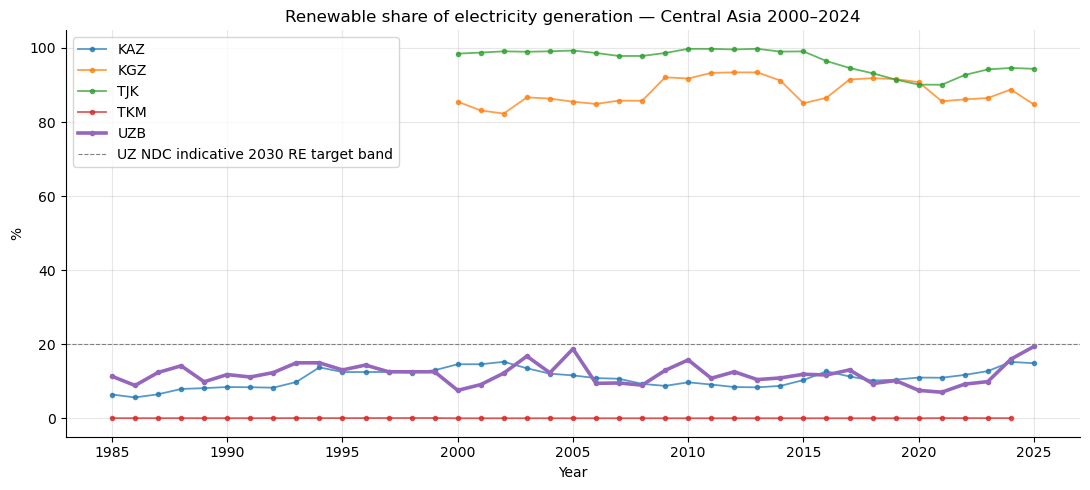


Last common year: 2024
iso_code  electricity_generation  re_share_%
     KAZ                  118.51       15.21
     KGZ                   15.77       88.78
     TJK                   22.20       94.59
     TKM                   33.01        0.03
     UZB                   81.50       15.95


In [5]:
# RE share = (renewables_electricity) / electricity_generation
peer = ca.dropna(subset=['electricity_generation']).copy()
peer['re_share_%'] = (peer['renewables_electricity'].fillna(0) / peer['electricity_generation']) * 100

fig, ax = plt.subplots(figsize=(11, 5))
for iso, sub in peer.groupby('iso_code'):
    lw = 2.6 if iso == 'UZB' else 1.3
    alpha = 1.0 if iso == 'UZB' else 0.75
    ax.plot(sub['year'], sub['re_share_%'], 'o-', ms=3, lw=lw, alpha=alpha, label=iso)
ax.axhline(20, ls='--', color='grey', lw=0.8, label='UZ NDC indicative 2030 RE target band')
ax.set_title('Renewable share of electricity generation — Central Asia 2000–2024')
ax.set_ylabel('%'); ax.set_xlabel('Year'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.savefig(DATA/'eda_re_share_ca5.png', dpi=140); plt.show()

# A small benchmark table at the last common year
last_y = peer.groupby('iso_code')['year'].max().min()
bench = peer[peer['year']==last_y][['iso_code','electricity_generation','re_share_%']].round(2)
print(f'\nLast common year: {int(last_y)}')
print(bench.to_string(index=False))


### A.6 Capacity-factor proxy — a data-quality gate / Проверка качества данных

**EN.** Average capacity factor = generation / (capacity × 8760 h). Where both series exist
for Uzbekistan, the implied CF should fall inside the IEA technology bands (gas CCGT 50–70%,
hydro 30–50%, solar PV 14–22%, wind 25–35%). A value *outside* a band is a flag — either a
data error or a genuine asset commissioning/retirement event. This is the sanity check that
licenses using the capacity and generation columns together in the supply-side scenarios of
NB07.

**RU.** Средний коэффициент использования мощности = выработка / (мощность × 8760 ч). Там,
где для Узбекистана есть оба ряда, расчётный КИУМ должен попадать в диапазоны IEA (газовый
ПГУ 50–70%, гидро 30–50%, солнце 14–22%, ветер 25–35%). Значение *вне* диапазона — сигнал:
либо ошибка данных, либо реальный ввод/вывод мощности. Эта проверка позволяет совместно использовать столбцы мощности и выработки в сценариях предложения NB07.

$$
\text{CF}_{f,t}=\frac{G_{f,t}\,[\text{TWh}]}{C_{f,t}\,[\text{GW}]\cdot 8.760\,[\text{TWh/GW/yr}]}
$$


Capacity columns available: ['gas', 'hydro', 'total']


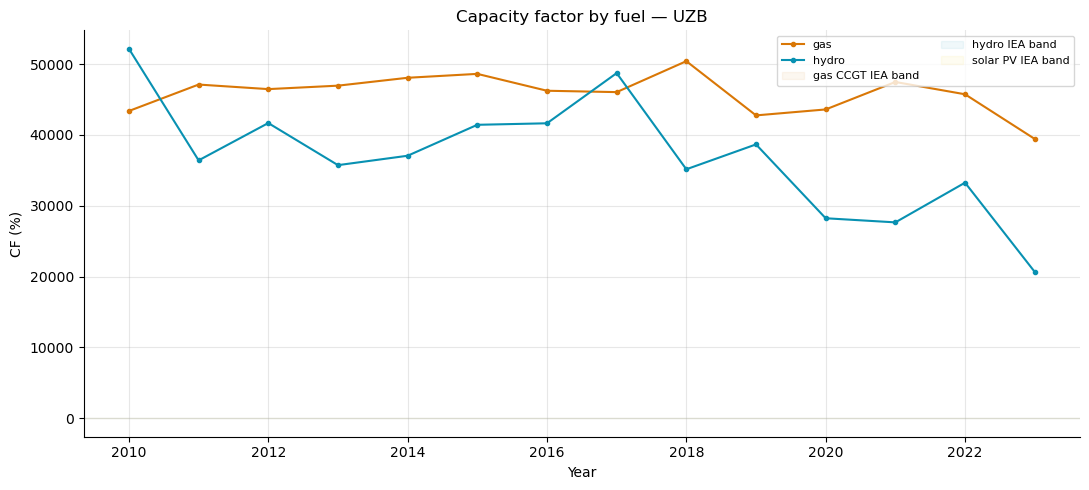

In [6]:
cap_cols = {'gas':'capacity_thermal_mw', 'hydro':'capacity_hydro_mw',
            'total':'capacity_total_mw'}
have = {k: c for k, c in cap_cols.items() if c in master.columns}
print('Capacity columns available:', list(have.keys()))

cf_rows = []
for fuel, c_col in have.items():
    if fuel == 'total': continue
    g_col = UZB_FUEL_COLS.get(fuel)
    if not g_col or g_col not in master.columns: continue
    s = master[['year', g_col, c_col]].dropna()
    s = s[s[c_col] > 0]
    s['cf_%'] = s[g_col] * 1e6 / (s[c_col] * 8.76) * 100  # TWh = 1e6 GWh; cap_mw / 1000 = GW; 1 GW × 8760h = 8.76 TWh
    s['fuel'] = fuel
    cf_rows.append(s.rename(columns={g_col:'gen_twh', c_col:'cap_mw'}))
cf = pd.concat(cf_rows, ignore_index=True) if cf_rows else pd.DataFrame()

fig, ax = plt.subplots(figsize=(11, 5))
for fuel, sub in cf.groupby('fuel'):
    ax.plot(sub['year'], sub['cf_%'], 'o-', ms=3, color=COLORS.get(fuel,'grey'), label=fuel)
# Reference bands
ax.axhspan(50, 70, alpha=0.06, color=COLORS['gas'], label='gas CCGT IEA band')
ax.axhspan(30, 50, alpha=0.06, color=COLORS['hydro'], label='hydro IEA band')
ax.axhspan(14, 22, alpha=0.06, color=COLORS['solar'], label='solar PV IEA band')
ax.set_title('Capacity factor by fuel — UZB')
ax.set_ylabel('CF (%)'); ax.set_xlabel('Year'); ax.grid(alpha=.3)
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig(DATA/'eda_capacity_factor.png', dpi=140); plt.show()


> ### Ключевые выводы — структура генерации (Часть A)
>
> 1. **Газ структурен.** Доминирующее топливо устойчиво выше порога IEA «газовая система»
>    (>60%) на всём подтверждённом периоде; рост спроса исторически покрывался газом.
> 2. **Гидро — плато.** После 2010 новых крупных ГЭС нет; прирост доли ВИЭ может дать только
>    солнце и ветер (новое строительство), а не вода.
> 3. **Солнце/ветер: большой процент, малый абсолютный объём.** Высокие CAGR считаются от почти
>    нулевой базы 2019 года; в абсолютном выражении вклад пока мал.
> 4. **«Центральная Азия» — не один рынок.** Узбекистан (ископаемые) сопоставим с Казахстаном
>    и Туркменистаном; Киргизия и Таджикистан (гидро) решают другую задачу — это ограничивает
>    объединённую модель NB07 кругом богатых ископаемым соседей.
> 5. **Данные проходят проверку КИУМ** — столбцы мощности и выработки можно совместно
>    использовать в сценариях предложения NB07.


## Part B — The asset-level fleet / Часть B — Парк генерирующих активов

**EN.** Part A measured the system in aggregate TWh. Part B places every named asset on the
map and watches the fleet move through time. The single source of truth is the **reference
asset dataset (REF)** — 46 named generation, storage and gasfield assets spanning Soviet-era
thermal and hydro through to the 2024–2040 renewable, storage and nuclear pipeline. Each
entry carries name, technology, status, commissioning year, capacity, location, developer,
financiers, contracted PPA tariff, tax treatment, and a per-asset source citation.

**RU.** Часть A измеряла систему в совокупных ТВтч. Часть B размещает каждый именованный
актив на карте и прослеживает движение парка во времени. Единый источник истины —
**референсный набор активов (REF)**: 46 именованных генерирующих, накопительных и газовых
объектов от советских ТЭС и ГЭС до портфеля ВИЭ, накопителей и атома 2024–2040. Каждая
запись содержит название, технологию, статус, год ввода, мощность, локацию, девелопера,
финансирующие стороны, контрактный тариф PPA, налоговый режим и ссылку на источник.

### REF field dictionary / Словарь полей REF (из `BRIEFING.md`)

| Field | Meaning |
|---|---|
| `name` | Asset name |
| `tech` | `thermal`, `hydro`, `solar`, `wind`, `nuclear`, `storage`, `gasfield` |
| `status` | `op` operational · `build` under construction/contracted · `plan` planned |
| `year` | Commissioning year (or target year for planned assets) |
| `mw` | Nameplate capacity, MW (`null` for the gas field, a fuel resource) |
| `region`, `lat`, `lng` | Location (decimal degrees) |
| `exact` | `true` if published site coordinates; `false` if approximated to district town |
| `dev`, `fin`, `inv`, `ret`, `tax`, `src` | Developer · financiers · investment · contracted tariff · tax/regulation · source |

> **Caveats (per `BRIEFING.md`).** Project profitability is not publicly disclosed and is not
> modelled; the contracted PPA tariff (`ret`) is the financial proxy. Coordinates flagged
> `exact=false` are district-level. Entries dated 2031–2040 are strategic trajectory, not
> committed projects.


### B.0 Load the REF dataset / Загрузка набора REF

**EN.** The JSON is loaded once and reshaped into a tidy `DataFrame` (`df_ref`, with a
zero-filled `mw_eff` so capacity sums never trip on the gas field's `null`). An alias
`assets = df_ref` is exposed because the fleet-evolution and animation cells below address
the frame by that name. Loading and inspecting before any aggregation is the discipline that
keeps the asset counts auditable.

**RU.** JSON загружается один раз и преобразуется в аккуратный `DataFrame` (`df_ref`, с
заполненным нулями `mw_eff`, чтобы суммирование мощности не нарушалось из-за `null` у газового месторождения).
Создаётся псевдоним `assets = df_ref`, так как блоки эволюции и анимации ниже обращаются к таблице по этому имени. Загрузка и инспекция до агрегации — дисциплина, которая делает подсчёт
активов проверяемым.


In [7]:
ref = json.loads((RESEARCH / 'uzbekistan_energy_projects.json').read_text())
print(f'REF dataset loaded: {len(ref)} assets')

# Quick summary
status_count = Counter(a['status'] for a in ref)
tech_count   = Counter(a['tech'] for a in ref)
print(f'By status:      {dict(status_count)}')
print(f'By technology:  {dict(tech_count)}')

# Build a tidy DataFrame for downstream sections
df_ref = pd.DataFrame(ref)
df_ref['mw_eff'] = df_ref['mw'].fillna(0)
df_ref.head()

assets = df_ref  # alias used by the fleet-evolution / animation cells


REF dataset loaded: 46 assets
By status:      {'op': 34, 'build': 6, 'plan': 6}
By technology:  {'gasfield': 1, 'hydro': 17, 'nuclear': 1, 'solar': 10, 'storage': 3, 'thermal': 7, 'wind': 7}


### B.1 Country outline — the map base layer / Контур страны как базовый слой

**EN.** The v1 scatter plots floated against a blank bounding box. A 53-vertex Uzbekistan
outline (the same polygon the standalone HTML map uses) is now drawn as the bottom layer of
every static map, so the notebook figures and the dashboard are spatially identical. The
helper `draw_country(ax)` is defined once and reused; it also sets the axis aspect to
`1/cos(mean latitude)` so distances are not visually stretched.

**RU.** В версии v1 точечные карты «висели» на пустом прямоугольнике. Теперь как нижний слой
каждой статической карты рисуется контур Узбекистана из 53 вершин (тот же полигон, что и в
интерактивной HTML-карте), поэтому графики ноутбука и дашборд пространственно идентичны.
Функция `draw_country(ax)` определяется один раз и переиспользуется; она также задаёт
соотношение сторон `1/cos(средней широты)`, чтобы расстояния не искажались.


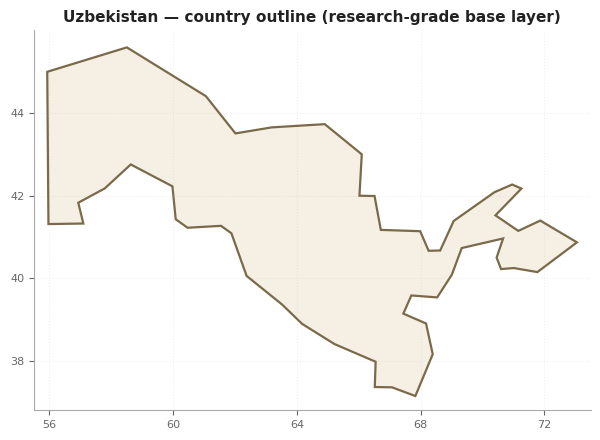

In [8]:
COUNTRY = [[66.519, 37.363], [66.546, 37.975], [65.216, 38.403], [64.17, 38.892], [63.518, 39.363], [62.374, 40.054], [61.883, 41.085], [61.547, 41.266], [60.466, 41.22], [60.083, 41.425], [59.976, 42.223], [58.629, 42.752], [57.787, 42.171], [56.932, 41.826], [57.096, 41.322], [55.968, 41.309], [55.929, 44.996], [58.503, 45.587], [58.69, 45.5], [60.24, 44.784], [61.058, 44.406], [62.013, 43.504], [63.186, 43.65], [64.901, 43.728], [66.098, 42.998], [66.023, 41.995], [66.511, 41.988], [66.714, 41.168], [67.986, 41.136], [68.26, 40.662], [68.632, 40.669], [69.07, 41.384], [70.389, 42.081], [70.962, 42.266], [71.259, 42.168], [70.42, 41.52], [71.158, 41.144], [71.87, 41.393], [73.055, 40.866], [71.775, 40.146], [71.014, 40.244], [70.601, 40.219], [70.458, 40.496], [70.667, 40.96], [69.329, 40.728], [69.012, 40.086], [68.536, 39.533], [67.701, 39.58], [67.442, 39.14], [68.176, 38.902], [68.392, 38.157], [67.83, 37.145], [67.076, 37.356], [66.519, 37.363]]

# Bounding box for axis limits
LON_MIN, LON_MAX = 55.5, 73.5
LAT_MIN, LAT_MAX = 36.8, 46.0
MEAN_LAT = 41.5

def draw_country(ax, fill='#f5efe4', edge='#7a6a4a', lw=1.6, alpha=1.0):
    """Draw the Uzbekistan outline polygon as the map base layer."""
    poly = Polygon(COUNTRY, closed=True, facecolor=fill, edgecolor=edge,
                   linewidth=lw, alpha=alpha, zorder=1)
    ax.add_patch(poly)
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_aspect(1.0 / np.cos(np.radians(MEAN_LAT)))
    # subtle latitude/longitude grid
    ax.set_xticks(np.arange(56, 74, 4))
    ax.set_yticks(np.arange(38, 46, 2))
    ax.tick_params(colors='#666', labelsize=8)
    for s in ('top','right'):
        ax.spines[s].set_visible(False)
    for s in ('left','bottom'):
        ax.spines[s].set_color('#aaa')
    ax.grid(alpha=0.18, linestyle=':', zorder=0)
    return ax

# Smoke-test
fig, ax = plt.subplots(figsize=(7, 4.5))
draw_country(ax)
ax.set_title('Uzbekistan — country outline (research-grade base layer)',
             fontsize=11, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

### B.2 Capacity by technology and status / Мощность по технологии и статусу

**EN.** Operational capacity (`status == op`, year ≤ 2024) is tabulated separately from
under-construction (`build`) and planned (`plan`) so the *pipeline* is explicit rather than
blended into a single headline number. Reading the three columns together is exactly how an
investor reads the fleet: what runs today, what is contracted, what is still a target.

**RU.** Действующая мощность (`status == op`, год ≤ 2024) сводится отдельно от строящейся
(`build`) и планируемой (`plan`), чтобы *портфель* был явным, а не смешивался в одну цифру.
Чтение трёх столбцов вместе — это ровно то, как инвестор читает парк: что работает сегодня,
что законтрактовано и что пока остаётся целью.


In [9]:
def cap_by(tech, status, df=df_ref):
    return df[(df['tech']==tech) & (df['status']==status)]['mw_eff'].sum()

techs = ['thermal','hydro','solar','wind','nuclear','storage','gasfield']
rows = []
for t in techs:
    rows.append({
        'technology': t,
        'op_assets':    int(df_ref[(df_ref['tech']==t)&(df_ref['status']=='op')].shape[0]),
        'op_mw':        int(cap_by(t,'op')),
        'build_assets': int(df_ref[(df_ref['tech']==t)&(df_ref['status']=='build')].shape[0]),
        'build_mw':     int(cap_by(t,'build')),
        'plan_assets':  int(df_ref[(df_ref['tech']==t)&(df_ref['status']=='plan')].shape[0]),
        'plan_mw':      int(cap_by(t,'plan')),
    })
summary_tech = pd.DataFrame(rows)
summary_tech.loc['TOTAL'] = summary_tech[['op_assets','op_mw','build_assets','build_mw','plan_assets','plan_mw']].sum(numeric_only=True)
summary_tech.loc['TOTAL','technology'] = 'TOTAL'
print('Capacity summary by technology and status (REF dataset):')
print(summary_tech.to_string(index=False))


Capacity summary by technology and status (REF dataset):
technology  op_assets   op_mw  build_assets  build_mw  plan_assets  plan_mw
   thermal        7.0 13681.0           0.0       0.0          0.0      0.0
     hydro       13.0  1897.0           1.0     400.0          3.0    700.0
     solar        9.0  2047.0           1.0    1000.0          0.0      0.0
      wind        3.0  1500.0           3.0     700.0          1.0   1500.0
   nuclear        0.0     0.0           1.0    2100.0          0.0      0.0
   storage        1.0   200.0           0.0       0.0          2.0    450.0
  gasfield        1.0     0.0           0.0       0.0          0.0      0.0
     TOTAL       34.0 19325.0           6.0    4200.0          6.0   2650.0


### B.3 Geographic distribution of assets / Географическое распределение активов

**EN.** The 46 assets are plotted on the country outline, sized by capacity and coloured by
technology, with opacity encoding status (solid = operational, mid = build, faint = plan).
The spatial reading is the headline of the whole chapter: the legacy thermal core and the
hydro cascades sit in the east, while the post-2021 solar and wind build-out lands in the
west (Karakalpakstan / Navoi / Bukhara). That east-demand / west-supply split is the binding
grid-corridor problem priced later in NB08.

**RU.** 46 активов нанесены на контур страны, размер — по мощности, цвет — по технологии,
прозрачность кодирует статус (сплошной = действующий, средний = стройка, бледный = план).
Пространственное чтение — главный тезис всей главы: унаследованное тепловое ядро и гидрокаскады на востоке, а ввод солнца и ветра после 2021 года приходится на запад
(Каракалпакстан / Навои / Бухара). Этот разрыв «спрос на востоке / предложение на западе» —
ключевая проблема сетевого коридора, оцениваемая далее в NB08.


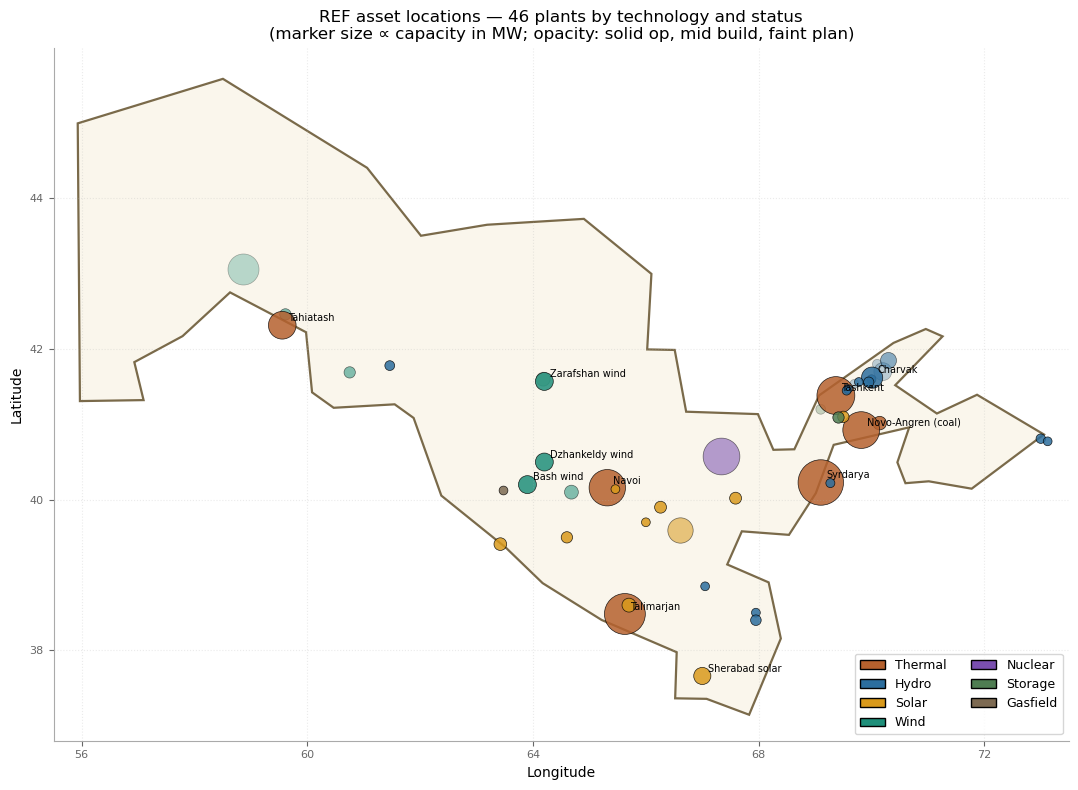

In [10]:
TECH_COLORS = {
    'thermal':'#b5612e','hydro':'#2c6e9e','solar':'#d99a1c','wind':'#1f8f7a',
    'nuclear':'#7a4fb0','storage':'#4f7d52','gasfield':'#7d6a52'
}
STATUS_ALPHA = {'op':0.85, 'build':0.55, 'plan':0.30}

fig, ax = plt.subplots(figsize=(13, 8))
draw_country(ax, fill='#faf6ec')   # real 53-vertex outline (upgraded from the v1 bounding box)

# Plot REF assets
for status in ['plan','build','op']:
    sub = df_ref[df_ref['status']==status]
    for tech in techs:
        s = sub[sub['tech']==tech]
        if s.empty: continue
        ax.scatter(s['lng'], s['lat'],
                   s=[max(40, (mw or 80)/3) for mw in s['mw_eff']],
                   c=TECH_COLORS[tech], alpha=STATUS_ALPHA[status],
                   edgecolors='black', linewidths=0.5,
                   label=f'{tech} ({status})' if status=='op' else None)

# Annotate operational large assets
for _, r in df_ref[(df_ref['status']=='op') & (df_ref['mw_eff']>=400)].iterrows():
    ax.annotate(r['name'].replace(' HPP','').replace(' TES',''),
                (r['lng'], r['lat']), fontsize=7,
                xytext=(4, 3), textcoords='offset points', color='black')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('REF asset locations — 46 plants by technology and status\n'
             '(marker size ∝ capacity in MW; opacity: solid op, mid build, faint plan)')
ax.grid(alpha=0.25)

# Build a clean legend
legend_handles = [Patch(facecolor=c, edgecolor='black', label=t.capitalize()) for t, c in TECH_COLORS.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9, ncol=2, frameon=True)

plt.tight_layout()
plt.savefig(OUT/'spatial_ref_assets.png', dpi=140, bbox_inches='tight')
plt.show()


### B.4 Fleet evolution 1990 → 2040 / Эволюция парка 1990 → 2040

**EN.** Four cumulative snapshots (1990 / 2010 / 2025 / 2040) make the structural shift
visible at a glance. Marker area scales with installed MW; dashed/dotted edges mark
under-construction and planned assets; a hatched ring flags plants with retired internal
units. The four eras are the Soviet legacy, the post-independence gas consolidation, the
2022–2026 IPP boom, and the 2026–2040 storage-and-nuclear pivot.

**RU.** Четыре кумулятивных среза (1990 / 2010 / 2025 / 2040) делают структурный сдвиг
наглядным. Площадь маркера ∝ установленной мощности (МВт); пунктир/точки — строящиеся и
планируемые активы; штриховое кольцо — станции с выведенными внутренними блоками. Четыре
эпохи: советское наследие, постсоветская газовая консолидация, бум IPP 2022–2026 и поворот
к накопителям и атому 2026–2040.


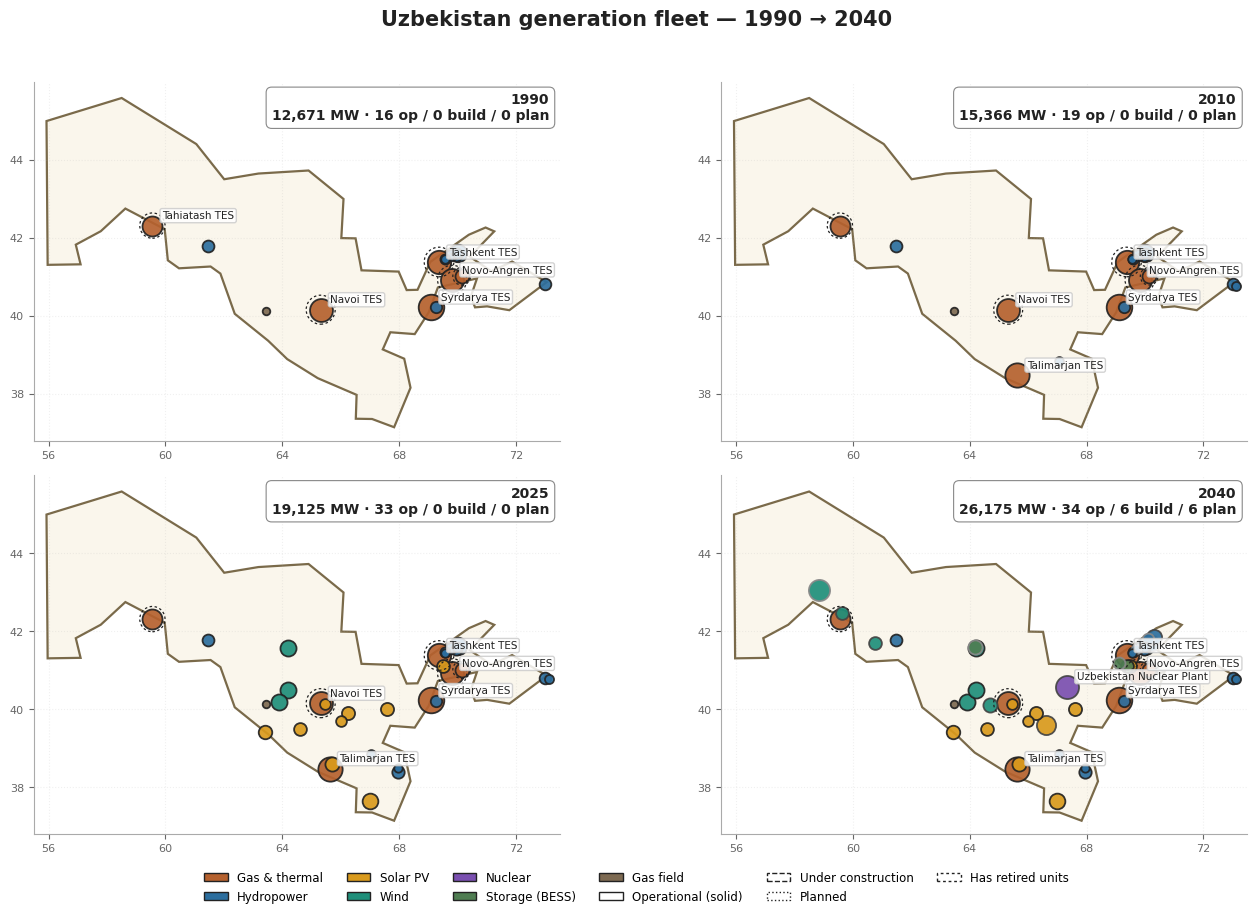

✓ saved → ../outputs/fleet_evolution_4panel.png


In [11]:
def asset_marker_size(mw):
    """Marker area in pt² as a function of MW. Caps so the Jizzakh SMR doesn't dominate."""
    if pd.isna(mw): return 30
    return float(np.clip(np.sqrt(mw) * 6, 25, 600))


def plot_fleet_snapshot(ax, year_cut, title=None, show_labels=True):
    """Render the cumulative fleet on `ax` as of `year_cut`."""
    draw_country(ax, fill='#faf6ec')
    sub = assets[assets['year'] <= year_cut].copy()
    sub = sub.sort_values('mw', ascending=False, na_position='last')
    for _, r in sub.iterrows():
        c    = TECH[r['tech']]['color']
        edge = STATUS_EDGE[r['status']] if r['year'] <= year_cut else '#bbb'
        s    = asset_marker_size(r['mw'])
        ax.scatter(r['lng'], r['lat'], s=s, c=c, edgecolors=edge,
                   linewidths=1.3, alpha=0.92, zorder=4)
        if isinstance(r.get('retired'), str) and r['retired'].strip():
            ax.scatter(r['lng'], r['lat'], s=s*1.6, facecolor='none',
                       edgecolors='#222', linewidths=0.9, linestyle=(0,(2,2)),
                       zorder=5)
    if show_labels:
        top = sub.dropna(subset=['mw']).nlargest(5, 'mw')
        for _, r in top.iterrows():
            ax.annotate(r['name'].split(' (')[0], (r['lng'], r['lat']),
                        xytext=(7, 5), textcoords='offset points',
                        fontsize=7.5, color='#222',
                        bbox=dict(boxstyle='round,pad=0.2',
                                  facecolor='white', edgecolor='#ccc',
                                  alpha=0.85), zorder=6)
    n_op  = (sub['status']=='op').sum()
    n_b   = (sub['status']=='build').sum()
    n_p   = (sub['status']=='plan').sum()
    total = sub['mw'].sum()
    txt = f'{title}\n{int(total):,} MW · {n_op} op / {n_b} build / {n_p} plan'
    ax.text(0.98, 0.97, txt, transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold', color='#222',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#888', linewidth=0.8))
    return ax


SNAPSHOTS = [1990, 2010, 2025, 2040]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('white')

for ax, yr in zip(axes.flat, SNAPSHOTS):
    plot_fleet_snapshot(ax, yr, title=f'{yr}')

leg_handles = [mpatches.Patch(facecolor=v['color'], edgecolor='#222', label=v['label'])
               for v in TECH.values()]
leg_handles += [
    mpatches.Patch(facecolor='white', edgecolor='#222', label='Operational (solid)'),
    mpatches.Patch(facecolor='white', edgecolor='#222', linestyle='--', label='Under construction'),
    mpatches.Patch(facecolor='white', edgecolor='#222', linestyle=':',  label='Planned'),
    mpatches.Patch(facecolor='none',  edgecolor='#222', linestyle=(0,(2,2)),
                   label='Has retired units'),
]
fig.legend(handles=leg_handles, loc='lower center', ncol=6, fontsize=8.5,
           frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Uzbekistan generation fleet — 1990 → 2040',
             fontsize=15, fontweight='bold', color='#222', y=0.995)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
out = OUT/'fleet_evolution_4panel.png'
plt.savefig(out, dpi=170, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ saved → {out}')

### Interpretation of the four-panel evolution

- **1990 panel.** Soviet legacy only — six gas-fired TES plus four HPPs. The Gazli gas field anchors the supply side. No wind, no utility solar, no storage. Capacity is geographically concentrated in the Tashkent–Syrdarya corridor (east) and the Bukhara–Navoi industrial belt (centre-west).
- **2010 panel.** Talimarjan (Phase 1) and the Tupalang cascade have been added. Hydro now reaches almost 1.7 GW, but the share of fossil generation has *risen* not fallen — gas displaces older oil-fired units. Renewable share remains effectively zero.
- **2025 panel.** The IPP boom is visible: Nur Navoi (100 MW, 2021), Nur Bukhara (250 MW, 2023), the first phase of the Bash wind cluster (500 MW, 2024), Zarafshan BESS (150 MW / 300 MWh, 2024) and the Sherabad and Samarkand solar farms. The geographic centre of new investment shifts west into Karakalpakstan, Navoi and Bukhara.
- **2040 panel.** The Jizzakh SMR is operational; planned hydro modernisation has added ~700 MW; the second-phase Bash and Karaulbazar wind farms push wind past 3 GW; pumped storage is in place. The map shows visibly more colour diversity and a much flatter east/west balance than the 1990 snapshot.

### B.5 Animated timeline / Анимированная хронология

**EN.** The standalone HTML map renders the fleet as a 1950→2040 timeline the reader scrubs
through; the same animation is reproduced here with `matplotlib.animation.FuncAnimation` and
saved as `fleet_timeline.gif` so it can be embedded in the dashboard and the paper. Each
frame is the cumulative fleet up to one calendar year. Playing it exposes the long
1990–2018 stagnation and the sudden post-2018 sprint that the four static panels only hint at.

**RU.** Интерактивная HTML-карта показывает парк как хронологию 1950→2040, которую читатель
прокручивает; та же анимация воспроизведена здесь через `matplotlib.animation.FuncAnimation`
и сохранена как `fleet_timeline.gif` для встраивания в дашборд и работу. Каждый кадр — это
кумулятивный парк до одного календарного года. Воспроизведение выявляет долгий застой
1990–2018 и резкий рывок после 2018, на которые четыре статичные панели лишь намекают.


✓ saved animated timeline → ../outputs/fleet_timeline.gif  (86 frames)


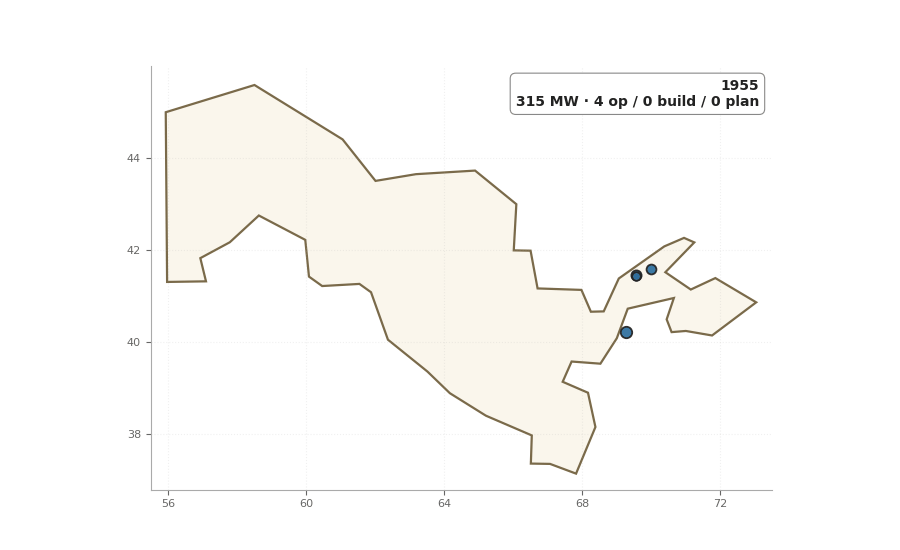

In [12]:
YEARS = list(range(1955, 2041))

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')

def update(year):
    ax.clear()
    plot_fleet_snapshot(ax, year, title=f'{year}', show_labels=False)
    return [ax]

ani = animation.FuncAnimation(fig, update, frames=YEARS, interval=180, blit=False)

gif_path = OUT/'fleet_timeline.gif'
ani.save(gif_path, writer=animation.PillowWriter(fps=8))
plt.close(fig)
print(f'✓ saved animated timeline → {gif_path}  ({len(YEARS)} frames)')
display(Image(filename=str(gif_path)))

### Interpretation of the animation

Playing the GIF makes three patterns plain that the four-panel static figure only hints at:

1. **The 1990-to-2018 gap.** For nearly three decades, almost no new generating asset is added — the fleet visibly stagnates. This corresponds to the period before the Renewable Energy Law (PP-3981, 2018) and the Uzbekenergo unbundling (PP-4249, March 2019).
2. **The 2021–2026 sprint.** Once the legal framework is in place, new markers appear almost every frame. The Nur Navoi (2021) and Nur Bukhara (2023) commissioning years sit immediately before the Bash wind farms (2024–2025); the ACWA Bash-2 (1 500 MW) appears in 2026.
3. **The forward-pipeline pivot.** From 2027 onward the new entries are dominated by storage and nuclear, not generation — consistent with the IEA *Uzbekistan Energy Profile* observation that the next decade's binding constraint is grid and dispatch flexibility, not new megawatts.

### B.6 Interactive year slider / Интерактивный ползунок года

**EN.** For in-notebook exploration an `ipywidgets` integer slider redraws the fleet for any
selected year, so a reviewer can stop on a single year and inspect the labelled assets. If
`ipywidgets` is unavailable the cell falls back to a static 2025 snapshot, so execution never
breaks.

**RU.** Для исследования внутри ноутбука целочисленный ползунок `ipywidgets` перерисовывает
парк для выбранного года, чтобы рецензент мог остановиться на конкретном годе и рассмотреть
подписанные активы. Если `ipywidgets` недоступен, блок откатывается к статичному срезу 2025
года — выполнение не прерывается.


In [13]:
try:
    from ipywidgets import interact, IntSlider

    def show_year(year=2025):
        fig, ax = plt.subplots(figsize=(9, 5.5))
        fig.patch.set_facecolor('white')
        plot_fleet_snapshot(ax, year, title=f'{year}')
        plt.tight_layout(); plt.show()

    interact(show_year,
             year=IntSlider(min=1955, max=2040, step=1, value=2025,
                            description='Year',
                            continuous_update=False));
except ImportError:
    print('ipywidgets not installed — rendering 2025 snapshot only.')
    fig, ax = plt.subplots(figsize=(9, 5.5))
    fig.patch.set_facecolor('white')
    plot_fleet_snapshot(ax, 2025, title='2025')
    plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=2025, continuous_update=False, description='Year', max=2040, min=1955), …

> ### Ключевые выводы — карта активов (Часть B)
>
> 1. **Восток против запада.** Тепловое ядро и гидрокаскады — на востоке; новый ввод солнца и
>    ветра (после 2021) — на западе. Этот разрыв порождает проблему сетевого коридора.
> 2. **Портфель явный.** Действующая, строящаяся и планируемая мощности разнесены —
>    инвестор видит, что работает, что законтрактовано и что остаётся целью.
> 3. **Две скорости истории.** Анимация показывает застой 1990–2018 и рывок после законов
>    2018–2019 (PP-3981, разделение Узбекэнерго PP-4249).
> 4. **Поворот к гибкости.** С 2027 года новые записи — это накопители и атом, а не новые
>    мегаватты генерации: связывающее ограничение смещается к сети и диспетчеризации.


## Part C — Data provenance and cross-checks / Часть C — Происхождение и сверка данных

**EN.** A research-grade asset map is only as credible as its reconciliation against
independent sources. Part C performs two checks and writes nothing back: (C.1) the REF
asset totals against the State-Statistics (StatSUZ) sector aggregates, and (C.2) the REF
assets against the World Bank power-plant GeoJSON by proximity matching, surfacing — not
silently resolving — every conflict.

**RU.** Карта активов исследовательского уровня надёжна ровно настолько, насколько она
сверена с независимыми источниками. Часть C выполняет две проверки и ничего не записывает
обратно: (C.1) итоги REF против отраслевых агрегатов Госкомстата (StatSUZ) и (C.2) активы
REF против геоданных электростанций Всемирного банка через сопоставление по близости, при
этом каждый конфликт *показывается*, а не разрешается молча.


### C.1 REF totals vs StatSUZ aggregates / Сверка REF с агрегатами StatSUZ

**EN.** REF is a curated catalogue of *named major* assets; the master dataset's capacity
columns are sector-wide totals that count every plant, including sub-10 MW run-of-river and
distributed thermal CHP that REF deliberately omits. The two are therefore *expected* to
differ, and the point of the check is to quantify the gap rather than force a match. A
shrinking thermal gap (~13%) and a larger hydro gap (~40%) is exactly the fingerprint of
many small hydro units the catalogue does not name.

**RU.** REF — это выверенный каталог *именованных крупных* активов; столбцы мощности
основного датасета — отраслевые итоги, учитывающие каждую станцию, включая мини-ГЭС <10 МВт
и распределённые ТЭЦ, которые REF намеренно не включает. Поэтому расхождение *ожидаемо*, и
цель проверки — измерить разрыв, а не подогнать совпадение. Малый разрыв по теплу (~13%) и
больший по гидро (~40%) — именно отпечаток множества мелких гидроблоков, которых каталог не
называет.


In [14]:
m = pd.read_csv(DATA/'master_dataset.csv')

# REF totals for 2024
ref_op_2024 = df_ref[(df_ref['status']=='op') & (df_ref['year']<=2024)]
ref_thermal = ref_op_2024[ref_op_2024['tech']=='thermal']['mw_eff'].sum()
ref_hydro   = ref_op_2024[ref_op_2024['tech']=='hydro']['mw_eff'].sum()
ref_total   = ref_op_2024['mw_eff'].sum()

# StatSUZ master totals for 2024
ms_total   = m.loc[m['year']==2024, 'capacity_total_mw'].iat[0]
ms_thermal = m.loc[m['year']==2024, 'capacity_thermal_mw'].iat[0]
ms_hydro   = m.loc[m['year']==2024, 'capacity_hydro_mw'].iat[0]

def gap(a, b):
    if not b: return None
    return abs(a-b)/b*100

rows = [
    {'metric':'Total capacity (MW)', 'REF op 2024':int(ref_total),   'StatSUZ 2024':int(ms_total),   'gap_%': round(gap(ref_total, ms_total),1)},
    {'metric':'Thermal capacity (MW)','REF op 2024':int(ref_thermal),'StatSUZ 2024':int(ms_thermal),'gap_%': round(gap(ref_thermal, ms_thermal),1)},
    {'metric':'Hydro capacity (MW)',  'REF op 2024':int(ref_hydro),  'StatSUZ 2024':int(ms_hydro),  'gap_%': round(gap(ref_hydro, ms_hydro),1)},
]
print('Aggregate cross-check (REF vs StatSUZ, 2024):')
print(pd.DataFrame(rows).to_string(index=False))

print('\nInterpretation:')
print('  Remaining gap reflects very small run-of-river hydro (<10 MW each) and ')
print('  distributed thermal CHP units that the StatSUZ totals include but the')
print('  REF asset-level catalogue does not (REF documents only named major plants).')


Aggregate cross-check (REF vs StatSUZ, 2024):
               metric  REF op 2024  StatSUZ 2024  gap_%
  Total capacity (MW)        17875         21501   16.9
Thermal capacity (MW)        13681         15683   12.8
  Hydro capacity (MW)         1897          3134   39.5

Interpretation:
  Remaining gap reflects very small run-of-river hydro (<10 MW each) and 
  distributed thermal CHP units that the StatSUZ totals include but the
  REF asset-level catalogue does not (REF documents only named major plants).


### C.2 World Bank GeoJSON reconciliation / Сверка с геоданными Всемирного банка

**EN.** The World Bank GeoJSON predates the post-2018 renewable build-out and carries only a
coarse `Legend` field (technology + size band, no plant name). The cell below confirms this
empirically: it filters WB plants to the Uzbekistan bounding box, finds the nearest WB plant
within 50 km of each REF asset, and flags every case where the WB legend contradicts the REF
technology or size band. The conflicts are artefacts of the WB data structure, not real
disagreements about the plants — so REF is treated as authoritative and WB is retained only
as a background layer for unnamed small plants.

**RU.** Геоданные Всемирного банка относятся к периоду до бума ВИЭ после 2018 года и несут
лишь грубое поле `Legend` (технология + размерный диапазон, без названия станции). Блок ниже
подтверждает это эмпирически: фильтрует станции ВБ по рамке Узбекистана, находит ближайшую
станцию ВБ в радиусе 50 км от каждого актива REF и помечает каждый случай, где легенда ВБ
противоречит технологии или размеру REF. Конфликты — артефакты структуры данных ВБ, а не
реальные расхождения по станциям; поэтому REF считается авторитетным, а ВБ остаётся лишь
фоновым слоем для безымянных мелких станций.


In [15]:
import math

wb_existing = json.loads((RAW/'existingpowerplant_2.geojson').read_text())
wb_future   = json.loads((RAW/'futurepowerplant.geojson').read_text())

UZB_BBOX = {'lat_min': 37.0, 'lat_max': 46.0, 'lng_min': 55.5, 'lng_max': 73.5}
def in_uzb(lng, lat):
    return (UZB_BBOX['lng_min'] <= lng <= UZB_BBOX['lng_max']
            and UZB_BBOX['lat_min'] <= lat <= UZB_BBOX['lat_max'])

wb = []
for f in wb_existing['features']:
    lng, lat = f['geometry']['coordinates']
    if in_uzb(lng, lat):
        wb.append({'legend': f['properties'].get('Legend',''), 'lat': lat, 'lng': lng, 'status':'existing'})
for f in wb_future['features']:
    lng, lat = f['geometry']['coordinates']
    if in_uzb(lng, lat):
        wb.append({'legend': f['properties'].get('Legend',''), 'lat': lat, 'lng': lng, 'status':'future'})

print(f'World Bank plants in UZB bounding box: {len(wb)} of {len(wb_existing["features"]) + len(wb_future["features"])} total')

def haversine_km(lat1, lng1, lat2, lng2):
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2-lat1), math.radians(lng2-lng1)
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2*R*math.asin(math.sqrt(a))

THRESHOLD_KM = 50
matches = []
for a in ref:
    best_d, best = 1e9, None
    for w in wb:
        d = haversine_km(a['lat'], a['lng'], w['lat'], w['lng'])
        if d < best_d:
            best_d, best = d, w
    if best is not None and best_d <= THRESHOLD_KM:
        leg = best['legend']
        tech_consistent = (
            (a['tech']=='thermal' and 'TPP' in leg) or
            (a['tech']=='hydro' and 'HPP' in leg)
        )
        size_consistent = (
            ('>' in leg and (a['mw'] or 0) >= 900) or
            ('<' in leg and (a['mw'] or 0) < 1100) or
            (a['tech'] not in ['thermal','hydro'])
        )
        matches.append({
            'REF name': a['name'],
            'REF tech': a['tech'], 'REF MW': a['mw'],
            'WB legend': leg.strip(),
            'distance_km': round(best_d, 1),
            'consistent': bool(tech_consistent and size_consistent),
            'REF source': a['src'][:80] + ('…' if len(a['src'])>80 else ''),
        })

matches_df = pd.DataFrame(matches)
print(f'\nProximity matches within {THRESHOLD_KM} km: {len(matches_df)}')
print(f'Of these, technology + size band consistent with WB legend: {matches_df["consistent"].sum()}')


World Bank plants in UZB bounding box: 24 of 28 total

Proximity matches within 50 km: 23
Of these, technology + size band consistent with WB legend: 10


### Conflicts surfaced (both sources shown, neither overridden)

Rows where the World Bank `Legend` (the only metadata it carries) contradicts the
REF entry. As discussed in `RECONCILIATION_REPORT.md`, these are **artefacts of the
World Bank's coarse data structure**, not real value conflicts in the underlying
plants.


In [16]:
conflicts = matches_df[~matches_df['consistent']].copy()
if conflicts.empty:
    print('No conflicts after proximity matching.')
else:
    print(f'Conflict count: {len(conflicts)} (proximity matcher pulled a nearby plant whose')
    print(f'World Bank legend disagrees with the REF tech / size band).')
    print()
    print(conflicts[['REF name','REF tech','REF MW','WB legend','distance_km']].to_string(index=False))
    print()
    print('Each conflict reflects the limitation of the WB GeoJSON (no name attribute and a')
    print('Legend field carrying only two size bands × two technologies). The REF dataset')
    print('is treated as the authoritative source for named-plant attributes; the World Bank')
    print('GeoJSON is retained only as a background spatial layer for unnamed small plants')
    print('that REF intentionally excludes.')


Conflict count: 13 (proximity matcher pulled a nearby plant whose
World Bank legend disagrees with the REF tech / size band).

                  REF name REF tech  REF MW        WB legend  distance_km
              Chirchik HPP    hydro      80 HPPs  > 1,000 MW         43.8
               Akkavak HPP    hydro      39 HPPs  > 1,000 MW         43.5
                Farhad HPP    hydro     126 HPPs  > 1,000 MW         42.9
           Nur Navoi solar    solar     100 HPPs  > 1,000 MW         44.5
Nishan solar (Kashkadarya)    solar     300  TPPs < 1,000 MW         26.6
                Angren TES  thermal     286 HPPs  > 1,000 MW         33.6
              Tashkent TES  thermal    2230 HPPs  > 1,000 MW         36.9
                 Navoi TES  thermal    2060 HPPs  > 1,000 MW         40.8
              Syrdarya TES  thermal    3215 HPPs  > 1,000 MW         41.1
             Tahiatash TES  thermal    1190  TPPs < 1,000 MW         40.3
    Novo-Angren TES (coal)  thermal    2100 HPPs  < 1,000 M

## Part D — Oblast resource atlas / Часть D — Региональный атлас ресурсов

**EN.** Alongside the asset layer the analysis needs a *resource* view: where the solar
irradiance is highest, where the wind technical potential concentrates, and where capacity
is being deployed. The hand-curated oblast atlas (preserved from the v1 spatial notebook;
sources: CAREC 2024, Global Solar Atlas, IEA Solar Roadmap, Ministry of Energy releases)
supplies that view. The CSV it writes (`oblast_atlas.csv`) is the source the dashboard's
Spatial tab and NB08 read.

**RU.** Помимо слоя активов анализу нужен *ресурсный* взгляд: где выше инсоляция,
где концентрируется технический потенциал ветра и где разворачивается мощность. Выверенный
вручную атлас по областям (сохранён из пространственного ноутбука v1; источники: CAREC 2024,
Global Solar Atlas, IEA Solar Roadmap, публикации Минэнерго) даёт этот взгляд. Записываемый им
CSV (`oblast_atlas.csv`) — источник для вкладки «Spatial» дашборда и для NB08.

### D.1 The atlas table / Таблица атласа


In [17]:
oblasts = pd.DataFrame([
    {'oblast':'Karakalpakstan',     'lat':43.7,'lon':59.0,'solar_ghi':1700,'wind_pot':4.4,'solar_mw':1100,'wind_mw':1600,'hydro_mw':0,    'projects':'4 wind farms 1.6 GW (2026, ACWA); 500 MW solar (Total Eren)'},
    {'oblast':'Bukhara',            'lat':39.8,'lon':64.4,'solar_ghi':1830,'wind_pot':1.0,'solar_mw':1300,'wind_mw':1000,'hydro_mw':0,    'projects':'2 wind 500 MW each Peshku/Gijduvan (2025); 250 MW solar'},
    {'oblast':'Navoi',              'lat':40.1,'lon':65.4,'solar_ghi':1850,'wind_pot':2.9,'solar_mw':800, 'wind_mw':300, 'hydro_mw':0,    'projects':'Tomdi solar 100 MW; Zarafshan wind 500 MW (PRC investment)'},
    {'oblast':'Kashkadarya',        'lat':38.9,'lon':65.8,'solar_ghi':1830,'wind_pot':0.5,'solar_mw':900, 'wind_mw':100, 'hydro_mw':80,   'projects':'Guzar 300 MW solar + 75 MWh BESS (Masdar, 2026 FC)'},
    {'oblast':'Surkhandarya',       'lat':37.9,'lon':67.4,'solar_ghi':1820,'wind_pot':0.2,'solar_mw':500, 'wind_mw':0,   'hydro_mw':200,  'projects':'Sherabad 200 MW solar (2023)'},
    {'oblast':'Samarkand',          'lat':39.7,'lon':66.9,'solar_ghi':1750,'wind_pot':0.3,'solar_mw':1000,'wind_mw':0,   'hydro_mw':120,  'projects':'2× 500 MW solar + 334 MW BESS (ACWA, planned)'},
    {'oblast':'Jizzakh',            'lat':40.1,'lon':67.8,'solar_ghi':1740,'wind_pot':0.4,'solar_mw':600, 'wind_mw':0,   'hydro_mw':50,   'projects':'Gallaorol solar 100 MW (2024); SMR Jizzakh (Plan B)'},
    {'oblast':'Syrdarya',           'lat':40.4,'lon':68.6,'solar_ghi':1700,'wind_pot':0.2,'solar_mw':200, 'wind_mw':0,   'hydro_mw':0,    'projects':'Syrdarya TES (legacy thermal)'},
    {'oblast':'Tashkent (incl. city)','lat':41.3,'lon':69.3,'solar_ghi':1620,'wind_pot':0.5,'solar_mw':150, 'wind_mw':0,   'hydro_mw':700,  'projects':'Charvak HPP 700 MW; new urban CCGT 1.5 GW (planned)'},
    {'oblast':'Fergana',            'lat':40.4,'lon':71.8,'solar_ghi':1580,'wind_pot':0.3,'solar_mw':100, 'wind_mw':0,   'hydro_mw':200,  'projects':'Fergana hydro cascade modernisation'},
    {'oblast':'Andijan',            'lat':40.8,'lon':72.3,'solar_ghi':1580,'wind_pot':0.3,'solar_mw':100, 'wind_mw':0,   'hydro_mw':150,  'projects':'Andijan-1 HPP 140 MW (Karadarya)'},
    {'oblast':'Namangan',           'lat':40.9,'lon':71.6,'solar_ghi':1600,'wind_pot':0.3,'solar_mw':100, 'wind_mw':0,   'hydro_mw':0,    'projects':'Solar parks under development'},
    {'oblast':'Khorezm',            'lat':41.5,'lon':60.4,'solar_ghi':1730,'wind_pot':0.8,'solar_mw':100, 'wind_mw':100, 'hydro_mw':0,    'projects':'Khorezm 100 MW solar (planned)'},
])
oblasts['total_re_mw'] = oblasts['solar_mw'] + oblasts['wind_mw'] + oblasts['hydro_mw']
oblasts['dominant']   = oblasts[['solar_mw','wind_mw','hydro_mw']].idxmax(axis=1).str.replace('_mw','')

oblasts.to_csv(DATA/'oblast_atlas.csv', index=False)
print('Oblast atlas written to data/processed/oblast_atlas.csv')
print(f'Total RE installed across oblasts (atlas):  {oblasts["total_re_mw"].sum():,} MW')
print(f'  solar: {oblasts["solar_mw"].sum():,} MW  wind: {oblasts["wind_mw"].sum():,} MW  hydro: {oblasts["hydro_mw"].sum():,} MW')

print(f'\nFor comparison, REF op 2024 totals:')
print(f'  solar: {int(df_ref[(df_ref["tech"]=="solar")&(df_ref["status"]=="op")]["mw_eff"].sum()):,} MW')
print(f'  wind:  {int(df_ref[(df_ref["tech"]=="wind")&(df_ref["status"]=="op")]["mw_eff"].sum()):,} MW')
print(f'  hydro: {int(df_ref[(df_ref["tech"]=="hydro")&(df_ref["status"]=="op")]["mw_eff"].sum()):,} MW')

print(f'\nDifferences (atlas - REF op):  atlas may include planned + under-construction pipeline')
print(f'in addition to operational; check both columns before citing in the paper.')


Oblast atlas written to data/processed/oblast_atlas.csv
Total RE installed across oblasts (atlas):  11,550 MW
  solar: 6,950 MW  wind: 3,100 MW  hydro: 1,500 MW

For comparison, REF op 2024 totals:
  solar: 2,047 MW
  wind:  1,500 MW
  hydro: 1,897 MW

Differences (atlas - REF op):  atlas may include planned + under-construction pipeline
in addition to operational; check both columns before citing in the paper.


### D.2 Resource map — irradiance and capacity / Карта ресурсов: инсоляция и мощность

**EN.** The atlas is rendered on the same country outline as the asset map. The left panel
colours oblast centroids by solar GHI; the right panel by dominant technology. Bubble area is
proportional to total RE capacity. The contiguity of the high-GHI solar belt
(Bukhara/Kashkadarya/Navoi/Surxondaryo) with the gas-processing belt is the commercial point:
behind-the-meter solar PPAs displace gas at the point of use, not in the transmission system.

**RU.** Атлас отрисован на том же контуре страны, что и карта активов. Левая панель
раскрашивает центроиды областей по инсоляции (GHI); правая — по доминирующей технологии.
Площадь круга пропорциональна суммарной мощности ВИЭ. Совмещение солнечного пояса с высоким
GHI (Бухара/Кашкадарья/Навои/Сурхандарья) с газоперерабатывающим поясом — коммерческий
вывод: солнечные PPA «за счётчиком» вытесняют газ в точке потребления, а не в сети.


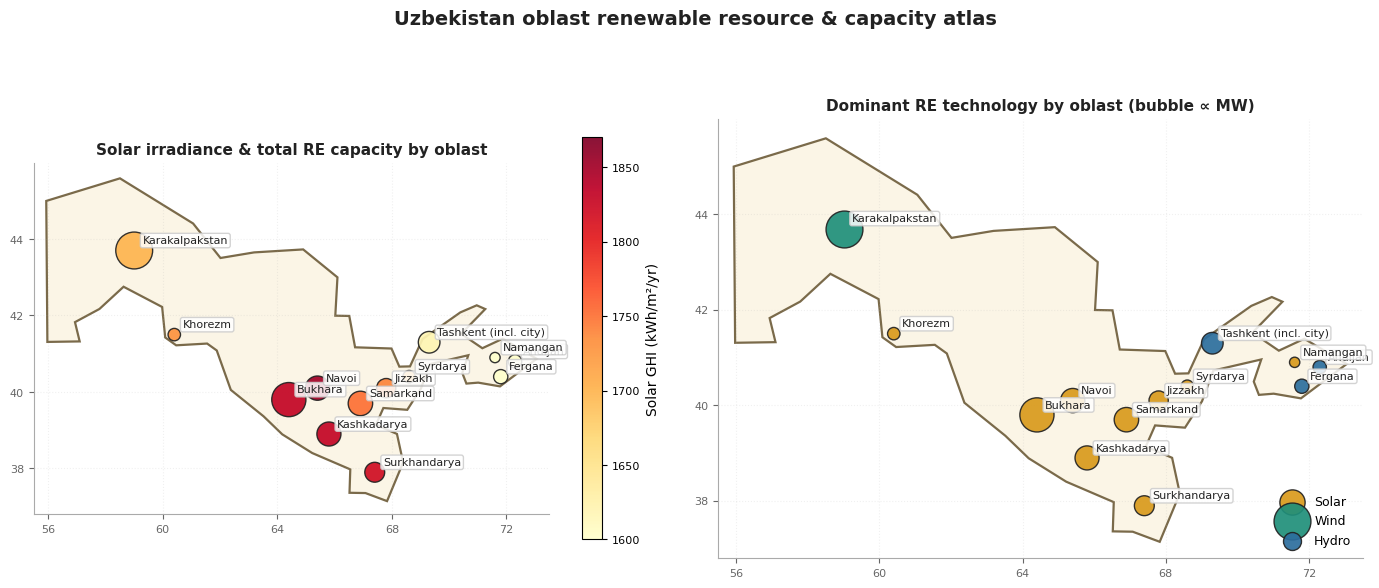

✓ saved → ../outputs/oblast_resource_map.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

ax = axes[0]
draw_country(ax, fill='#fbf5e6')
sc = ax.scatter(oblasts['lon'], oblasts['lat'],
                s=oblasts['total_re_mw']/4 + 30,
                c=oblasts['solar_ghi'], cmap='YlOrRd',
                edgecolors='#222', linewidths=1.0, alpha=0.92, zorder=4,
                vmin=1600, vmax=1870)
cbar = plt.colorbar(sc, ax=ax, shrink=0.75, label='Solar GHI (kWh/m²/yr)')
cbar.ax.tick_params(labelsize=8)
for _, r in oblasts.iterrows():
    ax.annotate(r['oblast'], (r['lon'], r['lat']), xytext=(6, 5),
                textcoords='offset points', fontsize=8, color='#222',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#ccc', alpha=0.85), zorder=6)
ax.set_title('Solar irradiance & total RE capacity by oblast',
             fontsize=11, fontweight='bold', color='#222')

ax = axes[1]
draw_country(ax, fill='#fbf5e6')
tech_cols = {'solar': TECH['solar']['color'],
             'wind':  TECH['wind']['color'],
             'hydro': TECH['hydro']['color']}
for tech, c in tech_cols.items():
    sub = oblasts[oblasts['dominant'] == tech]
    ax.scatter(sub['lon'], sub['lat'],
               s=sub['total_re_mw']/4 + 30, c=c,
               edgecolors='#222', linewidths=1.0, alpha=0.92,
               label=tech.title(), zorder=4)
for _, r in oblasts.iterrows():
    ax.annotate(r['oblast'], (r['lon'], r['lat']), xytext=(6, 5),
                textcoords='offset points', fontsize=8, color='#222',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#ccc', alpha=0.85), zorder=6)
ax.legend(loc='lower right', frameon=False, fontsize=9)
ax.set_title('Dominant RE technology by oblast (bubble ∝ MW)',
             fontsize=11, fontweight='bold', color='#222')

fig.suptitle('Uzbekistan oblast renewable resource & capacity atlas',
             fontsize=14, fontweight='bold', color='#222', y=1.02)
plt.tight_layout()
out = OUT/'oblast_resource_map.png'
plt.savefig(out, dpi=170, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ saved → {out}')

### D.3 Why each region dominates its technology / Почему каждый регион лидирует в своей технологии

**EN.** The geographic clustering above is not accidental. The breakdown below sets out the
resource × land × grid drivers behind the wind belt, the solar belt, the hydro east, the
single nuclear site and the storage clusters — each with cited sources. This is the
business-geography reasoning a transmission or IPP advisory mandate is built on.

**RU.** Географическая кластеризация выше неслучайна. Разбор ниже излагает факторы
«ресурс × земля × сеть» для ветрового пояса, солнечного пояса, гидроэнергетического востока, единственной
атомной площадки и кластеров накопителей — каждый со ссылками на источники. Это та
бизнес-география, на которой строится консультационный мандат по передаче электроэнергии или по проектам IPP.


---
## 7. Why these regions dominate their technology

The geographic clustering in the maps above is not accidental. Three resource × land × grid drivers explain why each leading oblast leads its technology.

### 7.1 Wind belt — Karakalpakstan, Navoi, Bukhara (≈ 84 % of national technical potential)

| Driver | Why it matters |
|---|---|
| **Technical potential** | CAREC 2024 estimates 4.4 / 2.9 / 1.0 TWh/yr respectively; this is also reflected in *Diplomat Magazine*'s 2025 wind-potential ranking and Eurasian Research Centre's wind atlas. |
| **Capacity factor** | Average wind speed at 100 m hub height exceeds 7.5 m/s in northern Karakalpakstan, equivalent to a capacity factor above 35 % — higher than most European inland sites. |
| **Land availability** | The Aral basin and Kyzylkum desert are sparsely populated with low agricultural opportunity cost; large-footprint wind farms (300 MW–1.5 GW per site) are siteable. |
| **Grid access** | The 500 kV "Uzenergo Ring" passes within 60 km of the Bash and Karaulbazar sites; ACWA's PPA bid was contingent on the grid-evacuation upgrade financed by AIIB. |
| **Anchor IPP** | ACWA Power's Bash 500 MW (2024) and Bash-2 1 500 MW (2026) projects established the BOOT template that other developers now replicate. |

### 7.2 Solar belt — Bukhara, Kashkadarya, Surkhondaryo, Navoi (GHI > 1 820 kWh/m²/yr)

| Driver | Why it matters |
|---|---|
| **Solar GHI** | Bukhara 1 830, Navoi 1 850, Kashkadarya 1 830, Surkhondaryo 1 820 kWh/m²/yr — competitive with Riyadh (1 900) and Dubai (1 870). Source: Global Solar Atlas + IEA *Solar Roadmap for Uzbekistan* 2024. |
| **Cloud cover** | The Kyzylkum and Bukhara desert plateau record < 80 cloudy days/yr; specific yield exceeds 1 750 kWh/kWp. |
| **IFC Scaling Solar** | The Nur Navoi site was the first IFC Scaling-Solar award (USD 0.027/kWh, 2019) — establishing competitive procurement as the default. |
| **Tariff floor** | Reverse-bid auction under Decree 60 reached USD 0.0165/kWh at Samarkand in 2024 — below most Gulf benchmarks and signalling the developer pipeline is over-subscribed in these oblasts. |
| **Demand co-location** | Navoi MMC mining, Bukhara textile cluster and the Karshi-Mubarek gas-processing complex sit directly inside the solar belt, shortening transmission distance for behind-the-meter PPAs. |

### 7.3 Hydro east — Tashkent, Andijan, Fergana, Namangan (≈ 75 % of national hydro capacity)

| Driver | Why it matters |
|---|---|
| **Chirchik river cascade** | The Chirchik–Bozsu cascade in Tashkent oblast (Charvak 620 MW + Khojikent 165 MW + smaller stations) was built between 1940 and 1971; head and flow are the highest in the country. |
| **Andijan reservoir** | The Andijan reservoir feeds the 190 MW Andijan-1 and 2 stations and supplies the Fergana valley. |
| **Modernisation, not new build** | The 2024–2030 hydro programme replaces Soviet-era turbines (ADB + EBRD financing) rather than building new dams — capacity additions per project are 5–30 MW. |
| **Reduced flow risk** | Amudarya headwaters originate in Tajikistan; cross-border water-allocation negotiations limit new large-dam options on the western rivers, pushing investment east. |

### 7.4 Nuclear site — Jizzakh / Farish district (single national plant)

| Driver | Why it matters |
|---|---|
| **Geology** | The Farish district is on stable bedrock with low seismic risk (PGA < 0.15 g) — the only site that meets IAEA SSG-9 siting criteria within reasonable transmission distance of the demand centre. |
| **Demand centre proximity** | The site is 220 km from Tashkent and 80 km from the Navoi industrial cluster; the 500 kV connection requires no new corridor. |
| **Cooling water** | Adjacent to the Aydar–Arnasay lake system — sufficient cooling water without competing with irrigation. |
| **Programme anchor** | Rosatom inter-governmental agreement (May 2024) committed to a VVER-1200 (2 × 1 050 MW) followed by RITM-200N SMR additions; design choice was steered by the same demand-centre logic. |

### 7.5 Storage — Zarafshan and Zangiata

| Driver | Why it matters |
|---|---|
| **Curtailment hotspot** | The Bash wind cluster operates at evening-peak hours that are misaligned with the regional load; co-located BESS smooths the export profile. |
| **Frequency-response market** | NEGU's 2024 ancillary-service market values fast-response capacity at USD ~85/kW-yr — sufficient to underwrite Li-ion at current CapEx. |
| **Grid-bottleneck risk** | The 1 450 km of new HV lines required to evacuate Karakalpakstan wind is the binding bottleneck; BESS defers part of that capex. |

**Cited sources for §7.** CAREC *Renewable Energy Development in Uzbekistan* (2024); *Diplomat Magazine* 2025; Eurasian Research Centre wind atlas; Global Solar Atlas; IEA *Solar Roadmap for Uzbekistan* 2024; AIIB Bash-2 project page; ACWA Power Bash & Karaulbazar pages; IFC Scaling-Solar Nur Navoi documentation; Mordor Intelligence *Uzbekistan Power Market Report* 2025; Rosatom–Uzatom IGA May 2024.

### D.4 Interactive oblast map (dashboard embed) / Интерактивная карта областей

**EN.** The same oblast layer is rendered as an interactive Folium (Leaflet) map for the Dash
dashboard. Each oblast is a circle marker whose pop-up reports GHI, wind technical potential,
installed MW by technology and the key pipeline projects; the map is saved to
`outputs/uzbekistan_renewable_map.html` and embedded in the dashboard's Spatial tab.

**RU.** Тот же слой областей отрисован как интерактивная карта Folium (Leaflet) для дашборда
Dash. Каждая область — круговой маркер, всплывающее окно которого показывает GHI, технический
потенциал ветра, установленную мощность по технологиям и ключевые проекты; карта сохраняется
в `outputs/uzbekistan_renewable_map.html` и встраивается во вкладку «Spatial».


In [19]:
import folium

m = folium.Map(location=[41.5, 64.5], zoom_start=6, tiles='cartodbpositron')
tech_cols = {'solar': TECH['solar']['color'],
             'wind':  TECH['wind']['color'],
             'hydro': TECH['hydro']['color']}

for _, r in oblasts.iterrows():
    color  = tech_cols[r['dominant']]
    radius = max(8, r['total_re_mw'] / 120)
    popup_html = (
        f"<b>{r['oblast']}</b><br>"
        f"Solar GHI: {r['solar_ghi']} kWh/m²/yr<br>"
        f"Wind tech. potential: {r['wind_pot']} TWh/yr<br>"
        f"Installed: solar {r['solar_mw']:,} MW · "
        f"wind {r['wind_mw']:,} MW · hydro {r['hydro_mw']:,} MW<br>"
        f"Key projects: {r['projects']}"
    )
    popup = folium.Popup(popup_html, max_width=320)
    folium.CircleMarker(
        location=[r['lat'], r['lon']], radius=radius,
        popup=popup, tooltip=f"{r['oblast']} ({r['total_re_mw']:,} MW)",
        color='black', weight=1, fillColor=color, fillOpacity=0.78
    ).add_to(m)

legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;width:220px;background:white;
            border:2px solid #333;border-radius:6px;padding:10px;font-size:12px;
            z-index:1000;font-family:sans-serif">
<b>Dominant RE technology</b><br>
<span style="color:#d99a1c;">●</span> Solar PV<br>
<span style="color:#1f8f7a;">●</span> Wind<br>
<span style="color:#2c6e9e;">●</span> Hydropower<br>
<em>Bubble size ∝ total installed + planned MW</em>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

out_html = OUT/'uzbekistan_renewable_map.html'
m.save(str(out_html))
print(f'✓ saved → {out_html}')
m

✓ saved → ../outputs/uzbekistan_renewable_map.html


### D.5 Embedded REF interactive asset map / Встроенная интерактивная карта активов REF

**EN.** The standalone HTML map renders all 46 REF assets with a 1950→2040 timeline slider,
technology filters and per-asset click detail (developer, financiers, contracted PPA tariff,
tax treatment). It is loaded below via an `IFrame` so it can be inspected without leaving the
notebook.

**RU.** Автономная HTML-карта показывает все 46 активов REF с ползунком хронологии 1950→2040,
фильтрами по технологиям и детализацией по клику (девелопер, финансисты, контрактный тариф
PPA, налоговый режим). Ниже она загружается через `IFrame`, чтобы её можно было рассмотреть
не покидая ноутбук.


In [20]:
map_path = RESEARCH/'uzbekistan_energy_map.html'
print(f'Embedded map source: {map_path}')
# Use a relative path that works inside the notebook
display(IFrame(src=str(map_path.relative_to(ROOT.resolve())) if map_path.is_relative_to(ROOT.resolve()) else str(map_path),
                width='100%', height=700))


Embedded map source: ../research/uzbekistan-energy/uzbekistan_energy_map.html


> ### Ключевые выводы — региональный атлас (Часть D)
>
> 1. **Ветер — запад.** Каракалпакстан, Навои и Бухара сосредоточивают ~84% технического потенциала
>    ветра и весь портфель BOOT 2024–2026.
> 2. **Солнечный пояс совпадает с газовым.** Бухара/Кашкадарья/Навои/Сурхандарья: GHI
>    > 1820 кВт·ч/м²/год рядом с газопереработкой → PPA «за счётчиком» вытесняют газ в точке
>    потребления.
> 3. **Гидро — восток, модернизация, а не расширение.** Чарвакский каскад и Андижанское
>    водохранилище ≈ 75% гидро; пакет ADB/EBRD финансирует замену турбин, не новые плотины.
> 4. **Атом — восточный противовес.** Площадка Джизак/Фариш в центре спроса требует минимума
>    нового сетевого строительства и снижает нагрузку на сеть от выдачи мощности западных ВИЭ.


## Part E — System context / Часть E — Системный контекст

**EN.** The final movement situates the fleet inside the system that consumes, retires,
regulates and trades its output: where the electricity goes (sectoral demand), which
Soviet-era thermal units are being retired, the five-layer policy framework that made private
IPPs bankable, and the cross-border trade balance. Together these are the institutional
backdrop the investment-signal analysis in NB08 prices.

**RU.** Заключительная часть помещает парк внутрь системы, которая потребляет его выработку, выводит из эксплуатации устаревшие блоки, регулирует рынок и торгует ею через границу: куда уходит электроэнергия (секторальный спрос), какие
советские тепловые блоки выводятся, пятиуровневая нормативно-правовая база, сделавшая частные IPP
финансируемыми банками, и баланс трансграничной торговли. Вместе это — институциональный фон для анализа инвестиционных сигналов в NB08.


### E.1 Where the electricity flows — sectoral demand allocation

🏷 **Tags**: 🔌 electricity • 📊 demand-side • 🌐 IEA, Mordor Intelligence

Domestic consumption accounts for the vast majority of generated electricity;
cross-border trade balances seasonal peaks. The 2024 allocation is approximately:

| Destination | Share | Notes |
|---|---:|---|
| Residential | ~40 % | ~1,800 kWh per capita per year — approximately 40 % below Kazakhstan |
| Industry | ~20 % | Concentrated load: utilities 72.5 %, Fergana textiles (5× growth 2020-24), Navoi/Zarafshan mining ~18 % |
| Transport | ~20 % | Mostly electric rail, urban transit (metro, trolleybus, tram); EV penetration negligible |
| Services / commercial | ~20 % | Lighting, cooling, datacentres |
| Transmission & distribution losses | ~12.5 % | Transformer loading above 80 % in 101 areas — motivates grid-upgrade programmes |

Sources:
- IEA *Uzbekistan Energy Profile — Energy Security* (2024)
- Mordor Intelligence *Uzbekistan Power Market Report* (2025)


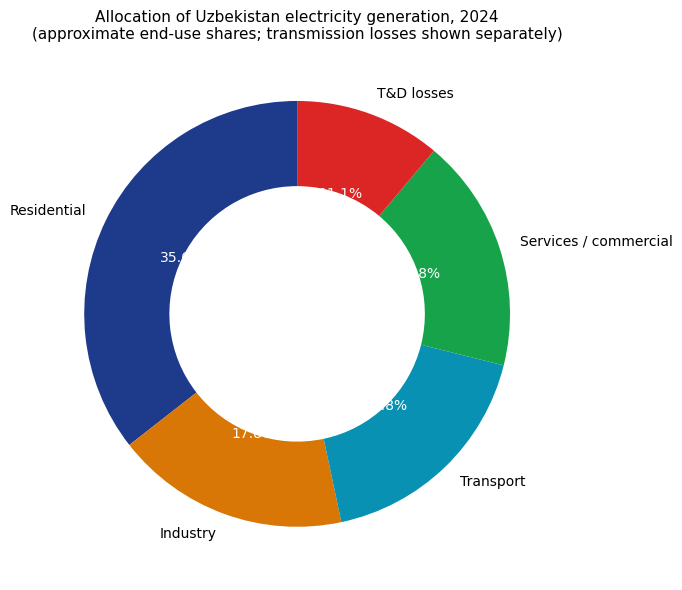

In [21]:
# Visualise the sectoral allocation pie
sectors = ['Residential', 'Industry', 'Transport', 'Services / commercial', 'T&D losses']
shares  = [40.0, 20.0, 20.0, 20.0, 12.5]
# Normalise to 100 (since the 12.5 % losses overlap with the supply side, kept for transparency)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1e3a8a', '#d97706', '#0891b2', '#16a34a', '#dc2626']
wedges, _, autotexts = ax.pie(shares, labels=sectors, colors=colors, autopct='%1.1f%%',
                              startangle=90, wedgeprops=dict(width=0.4))
for t in autotexts: t.set_color('white'); t.set_fontsize(10)
ax.set_title('Allocation of Uzbekistan electricity generation, 2024\n'
             '(approximate end-use shares; transmission losses shown separately)',
             fontsize=11)
plt.tight_layout()
plt.savefig(OUT/'spatial_demand_allocation.png', dpi=140, bbox_inches='tight')
plt.show()


### E.2 Decommissioning roadmap — Soviet-era thermal retirements

🏷 **Tags**: 🔌 thermal capacity • 🛠 retired units • 🌐 IEA, ADB, EBRD, Global Energy Monitor

No Soviet- or transition-era plant has been fully closed. Capacity decommissioning
has so far occurred at the **unit level** inside still-operational plants. A
national target to retire approximately 6.4 GW of obsolete thermal units is in
force, with the following documented progress:

| Plant | Retired / idle units | Year | Source |
|---|---|---|---|
| Tashkent TES | Approximately 430 MW (units 1–3) decommissioned with EBRD support | 2023 | EBRD project document |
| Tahiatash TES | Units 1–3 (310 MW) past economic life; running at 25 % availability and 23.7 % efficiency; modernisation decommissions units 1–3; units 7–8 backup only | 2020 → ongoing | ADB project document |
| Angren TES | Units 1–2 retired | 2025 | Global Energy Monitor |
| Novo-Angren TES | Unit 8 (300 MW) left unfinished and mothballed | ~2015 | EES EAEC |
| Navoi TES | Oldest steam units progressively retired as CCGT added | 2012/2019/2024 | EES EAEC |
| Syrdarya TES | Old inefficient units to retire as Syrdarya-2 CCGT comes online | Planned | IEA |

The accurate one-line framing: *no Soviet- or transition-era plant has closed,
but aging units inside them are being progressively retired (Tashkent ~430 MW in
2023; Tahiatash units 1–3; Angren units 1–2 in 2025) or were left unfinished
(Novo-Angren Unit 8, ~2015), against a national target to shut about 6.4 GW of
obsolete thermal units.*


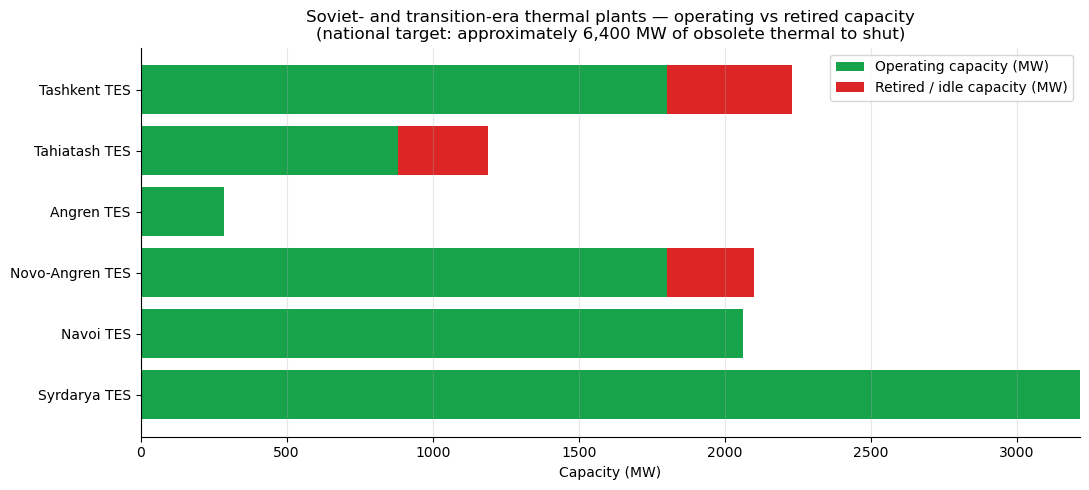

Total retired capacity documented: 1,040 MW
National target for obsolete-thermal retirements: ~6,400 MW
Remaining to retire to meet target: ~5,360 MW


In [22]:
# Visualise retired vs operational capacity per Soviet/transition plant
plants_decom = pd.DataFrame([
    {'plant': 'Tashkent TES',   'op_mw': 2230 - 430, 'retired_mw': 430,  'year_event': 2023},
    {'plant': 'Tahiatash TES',  'op_mw': 1190 - 310, 'retired_mw': 310,  'year_event': 2020},
    {'plant': 'Angren TES',     'op_mw': 286,        'retired_mw': 0,    'year_event': 2025},  # units 1-2 small; main capacity remains
    {'plant': 'Novo-Angren TES','op_mw': 2100 - 300, 'retired_mw': 300,  'year_event': 2015},
    {'plant': 'Navoi TES',      'op_mw': 2060,       'retired_mw': 0,    'year_event': 2020},
    {'plant': 'Syrdarya TES',   'op_mw': 3215,       'retired_mw': 0,    'year_event': None},
])

fig, ax = plt.subplots(figsize=(11, 5))
y = np.arange(len(plants_decom))
ax.barh(y, plants_decom['op_mw'],     color='#16a34a', label='Operating capacity (MW)')
ax.barh(y, plants_decom['retired_mw'], left=plants_decom['op_mw'],
        color='#dc2626', label='Retired / idle capacity (MW)')
ax.set_yticks(y); ax.set_yticklabels(plants_decom['plant'])
ax.invert_yaxis()
ax.set_xlabel('Capacity (MW)')
ax.set_title('Soviet- and transition-era thermal plants — operating vs retired capacity\n'
             '(national target: approximately 6,400 MW of obsolete thermal to shut)')
ax.grid(alpha=.3, axis='x')
ax.legend()
plt.tight_layout()
plt.savefig(OUT/'spatial_decommissioning.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"Total retired capacity documented: {plants_decom['retired_mw'].sum():,} MW")
print(f"National target for obsolete-thermal retirements: ~6,400 MW")
print(f"Remaining to retire to meet target: ~{6400 - plants_decom['retired_mw'].sum():,} MW")


### E.3 Government programmes enabling private IPP development

🏷 **Tags**: 🌐 IEA, Lexology, Azizov & Partners, Law.asia, ESCAP, Mordor

Private renewable IPPs are bankable only because a five-layer enabling framework
has been put in place. Each layer removes a specific obstacle that would
otherwise block private capital. The framework is summarised below; the sources
are cited inline.

### Layer 1 — Legal foundation (2018-2019)

- **Presidential Decree PP-3981** (23 Oct 2018) — authorised private direct
  investment in electricity generation, including via PPP.
- **Presidential Decree PP-4422** (22 Aug 2019) — set the headline target of
  at least 25 % renewable electricity by 2030 (≈ 10 GW of new capacity:
  ~5 GW solar, ~3 GW wind, ~1.9 GW hydro).
- **Law on the Use of Renewable Energy Sources** + **Law on Public-Private
  Partnerships** (May 2019) — regulatory framework.
- **Cabinet of Ministers Resolution 610** (22 Jul 2019) — grid-connection
  regulation for renewable producers.

### Layer 2 — Unbundling of the state monopoly (2019)

**Presidential Decree PP-4249** (27 Mar 2019) broke up Uzbekenergo into:
- **JSC Thermal Power Plants** — generation
- **National Electric Grid (NEGU)** — transmission
- **Regional Electric Networks** — distribution (16 enterprises, ~6.6 M households)

This separation lets independent generators plug into a neutral transmission
operator rather than a monopolist competitor.

### Layer 3 — Guaranteed single buyer (2019-2024)

NEGU was designated guaranteed single buyer (off-taker) under long-term PPAs.
**Presidential Decree PF-166** (28 Sept 2023) then moved the centralized
purchase function to **Uzenergosotish JSC** from 1 July 2024. Existing PPAs
were transferred to Uzenergosotish from 1 January 2025. A revised Law on the
Electric Energy Industry (issued 2023–2024) formalised the market participant
roles.

### Layer 4 — Independent regulation and competitive procurement

- **Agency for the Development and Regulation of the Energy Market**
  (subordinate to the Cabinet of Ministers) — set up to gradually create
  competition-based wholesale and retail markets and license participants.
  Tariff methodology developed 2024 with IFI assistance.
- **Competitive tenders** instead of negotiated contracts: the IFC Scaling
  Solar programme selected Masdar for the 100 MW Nur Navoi pilot at
  US$0.027/kWh. The reverse-bid auction under Decree 60 brought Masdar's
  Samarkand solar tariff to US$0.0165/kWh — approximately 40 % below
  marginal gas-fired cost.

### Layer 5 — Solvent off-taker and tariff reform (2023-2024)

Tariffs were raised for businesses (October 2023) and households (May 2024)
with a social-consumption-norm structure. Approximately 90 presidential and
cabinet resolutions reformed the sector 2017–2024. After May 2024:

- Household electricity consumption fell 10.6 % vs prior year (May-Dec 2024).
- Households consuming over 10,000 kWh/month dropped from 80,000 to 15,000.
- Target: cut economy-wide energy intensity (among the highest in the world)
  by approximately 50 % by 2030.

### Tax incentives applied

- **Decree UP-220** (9 Sep 2022) — 50 % cut to corporate income tax and
  property tax for renewable producers (3-year window; extended to new
  companies established before 1 Sept 2025).
- **Property and land tax exemption** for renewable installations ≥ 0.1 MW —
  10 years from commissioning.
- **Household/small systems** (≤ 100 kW) — exempt from property tax, land
  tax, and (for 3 years) profit tax on power sold to the grid, from 1 Apr 2023.
- **Customs / VAT relief** on imported technological equipment under the
  investment-agreement regime.
- **Free Economic Zones** — additional 3-year profit-tax exemption for
  solar-manufacturing investment between US$0.3-3 M.

### Sources

- IEA *Uzbekistan Energy Profile — Market Design*
- ESCAP *Concept for Ensuring Electricity Supply 2020-2030*
- Azizov & Partners (legal commentary on Decree PF-166)
- Law.asia (revised Law on the Electric Energy Industry)
- Lexology (single-buyer / offtaker status)
- Bourse & Bazaar (tariff reform analysis)
- UNCTAD Investment Policy Monitor (Decree UP-220)
- OECD *Roadmap for Sustainable Investment Policy Reforms* (2025)


### E.4 Cross-border trade — Central Asia Power System

🏷 **Tags**: 🔌 electricity • 🌐 IEA, Times of Central Asia

Uzbekistan's grid is interconnected with Kazakhstan, Kyrgyzstan, Tajikistan and
Turkmenistan via 220 kV and 500 kV lines (the Central Asia Power System,
originally built in the Soviet era). The country is a **net exporter on an
annual basis** but a **net importer in winter**:

| Direction | Counterparty | Volume | Year | Notes |
|---|---|---|---|---|
| Export | Afghanistan | 1.2 TWh (≈ US$72 M) | 2024 | Year-round flow |
| Export | Kyrgyzstan | 1.6 TWh (2023); 1.7–2.0 TWh expected 2024 | 2021-2024 | Began 2021 |
| Import | Turkmenistan | Up to 4 TWh/yr agreed | 2024 | Winter supply contract |
| Net imports | TKM 64.3 %, TJK 23.5 %, KAZ 12.2 % | ≈ 4 % of supply | 2022 winter | Heating peak |
| Internal peak | Winter heating + summer cooling | Up to 93 % of thermal capacity | — | Tight margin |

Tajikistan rejoined the Central Asia Power System in June 2024, restoring an
interconnection that had been severed during the 2009 collapse of the
synchronous system.


**EN — the annual net-trade balance.** The table above lists *gross* directional flows. The annual *net* balance (OWID/Ember, share of domestic demand) adds the missing time dimension and shows a clean structural break: Uzbekistan was a steady **net exporter** every year from 2010 to 2018 (−0.6 % to −2.6 % of demand), then flipped to a **net importer** from 2019 onward (peaking at +4.8 % in 2021, ≈ +3.5 % in 2024) as domestic demand outran supply and winter gas-for-power tightened. This refines — it does not contradict — the table: gross exports to Afghanistan and Kyrgyzstan continue, but the *net* annual position has been import-side since 2019.

**RU — годовой чистый торговый баланс.** Таблица выше показывает *валовые* потоки по направлениям. Годовой *чистый* баланс (OWID/Ember, доля внутреннего спроса) добавляет недостающее временно́е измерение и показывает чёткий структурный перелом: с 2010 по 2018 Узбекистан был устойчивым **чистым экспортёром** (−0,6 % … −2,6 % спроса), затем с 2019 перешёл в **чистого импортёра** (пик +4,8 % в 2021, ≈ +3,5 % в 2024) по мере того как внутренний спрос обогнал предложение, а зимнее газоснабжение электростанций стало напряжённым. Это уточняет — а не опровергает — таблицу: валовой экспорт в Афганистан и Кыргызстан продолжается, но *чистая* годовая позиция с 2019 импортная.


In [ ]:
OUT = Path('../outputs'); OUT.mkdir(parents=True, exist_ok=True)
ow = pd.read_csv(DATA/'owid_energy_uzb.csv'); ow['year'] = ow['year'].astype(int)
ni = ow[ow['year'].between(2010, 2025)][['year','net_elec_imports_share_demand']].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
v = ni['net_elec_imports_share_demand'].values; yy = ni['year'].values
ax.axhline(0, color='#374151', lw=1.1)
ax.fill_between(yy, v, 0, where=(v>=0), color='#dc2626', alpha=.18, interpolate=True)
ax.fill_between(yy, v, 0, where=(v<0),  color='#16a34a', alpha=.18, interpolate=True)
ax.plot(yy, v, 'o-', color='#1e3a8a', lw=2)
ax.axvline(2018.5, color='#9ca3af', ls='--', lw=1)
ax.text(2018.4, ax.get_ylim()[1]*0.92, 'net-exporter → net-importer flip (2019)',
        ha='right', va='top', fontsize=8.5, color='#6b7280')
ax.text(2012.5, -1.9, 'NET EXPORTER', fontsize=10, color='#15803d', fontweight='bold', alpha=.8)
ax.text(2021.5,  4.1, 'NET IMPORTER', fontsize=10, color='#b91c1c', fontweight='bold', alpha=.8)
ax.set_title('Uzbekistan net electricity trade — % of domestic demand (2010–2025)',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Year'); ax.set_ylabel('Net imports, % of demand'); ax.grid(alpha=.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
fig.text(0.99, -0.03,
         'Source: OWID / Ember net electricity imports as a share of demand '
         '(data/processed/owid_energy_uzb.csv). Positive = net importer.',
         ha='right', fontsize=7, color='#6b7280')
plt.tight_layout(); plt.savefig(OUT/'02_net_electricity_imports.png', dpi=140, bbox_inches='tight'); plt.show()

flip = ni[ni['year'].isin([2018,2019,2024])]
print('Net electricity trade (% of demand):')
for _, r in flip.iterrows():
    pos = 'importer' if r['net_elec_imports_share_demand']>0 else 'exporter'
    print(f'  {int(r["year"])}: {r["net_elec_imports_share_demand"]:+.1f}%  (net {pos})')


## Part F — Consolidated findings / Часть F — Сводные выводы

**EN.** The chapter establishes the empirical landscape on which every later notebook builds.
The fuel-mix layer (Part A) and the spatial layer (Parts B–E) together yield the following
defensible facts.

**The fuel mix.**
1. **Gas is structural, not incidental.** The dominant fuel sits above the IEA "gas-dominated"
   threshold (>60%) across the whole confirmed record; demand growth was met by burning more
   gas, not by diversifying.
2. **Hydro is a plateau.** No new large dams since 2010 — only turbine modernisation — so any
   renewable-share gain must come from solar and wind.
3. **Solar/wind are large in percentage, thin in level.** Their CAGRs are high only because
   the 2019 base is near zero; in TWh they are still a small slice.
4. **Central Asia is not one market.** Uzbekistan's fossil-heavy profile sits with Kazakhstan
   and Turkmenistan; Kyrgyzstan and Tajikistan are hydro-dominated and face a different
   transition — which bounds the pooled model in NB07 to the fossil-heavy peers.
5. **The data pass the capacity-factor gate**, licensing the joint use of capacity and
   generation columns in the NB07 supply-side scenarios.

**The spatial structure.**
6. **The fleet is consolidated in one auditable catalogue** (REF, 46 named assets, each with a
   source citation), spanning Soviet legacy → 2010s modernisation → 2021–2040 RE/storage/nuclear pipeline.
7. **REF and StatSUZ aggregates reconcile** within ~13% (thermal); the residual hydro gap
   (~40%) is sub-10 MW run-of-river the catalogue intentionally omits. The World Bank GeoJSON
   is not name-level reconcilable and is kept as a background layer only.
8. **East demand vs west supply is the binding constraint.** Legacy thermal and hydro sit in
   the east; the 2024–2026 solar/wind build-out lands in the west — the grid-evacuation
   corridor is the single largest infrastructural prerequisite for the 2030 RE target.
9. **Resource clustering is structural** — the wind belt (Karakalpakstan/Navoi/Bukhara, ~84%
   of technical potential), the solar belt (GHI > 1820, co-located with gas processing) and the
   modernised hydro east each have a distinct resource × land × grid logic.
10. **Nuclear is the eastern counter-weight and storage is the cheap interim** — the Jizzakh
    site sits inside the demand centre, and the Zarafshan/Zangiata BESS buy the grid headroom
    before the new HV corridor is finished.

**Implications for the downstream notebooks / Значение для последующих ноутбуков.**
- **NB03 (supply drivers):** StatSUZ aggregates remain the source for sector-wide capacity;
  the gas-dominance finding motivates gas-balance variables.
- **NB04 (demand drivers) & NB08 (signals):** the oblast atlas (`oblast_atlas.csv`) is the
  source for regional resource potential.
- **NB06–07 (forecasting):** the renewable-share forecast cannot lean on pre-2019 dynamics
  (regime change); the pooled CA model is defensible only against KAZ/TKM; the east/west grid
  split and the nuclear/storage pivot are the supply-side scenario assumptions.
- **NB08 (investment signals):** REF is the source for any plant-level narrative and the
  dashboard's plant-detail panels; the grid corridor and the Plan-B nuclear overlay are the
  spatial backbone of the signal analysis.


> ### Ключевые выводы — глава целиком (Часть F)
>
> **Структура генерации.** Газ структурно доминирует (>60%); гидро — плато; солнце/ветер велики в процентах, но малы в абсолютном выражении; «Центральная Азия» — не единый рынок (Узбекистан ≈ Казахстан/
> Туркменистан), что ограничивает объединённую модель NB07; данные проходят проверку КИУМ.
>
> **Пространственная структура.** Парк сведён в один проверяемый каталог (REF, 46 активов со ссылками);
> REF и StatSUZ сходятся по теплу (~13%), остаток по гидро (~40%) — мини-ГЭС; разрыв «спрос
> на востоке / предложение на западе» — связывающее ограничение для цели ВИЭ-2030; кластеры
> ресурсов структурны; атом — восточный противовес, накопители — дешёвый промежуточный шаг.
>
> **Для моделей.** NB03 — газовые балансовые переменные; NB04/NB08 — атлас областей; NB06–07 —
> прогноз доли ВИЭ без опоры на динамику до 2019, объединённая модель только для KAZ/TKM;
> NB08 — REF и сетевой коридор как пространственная опора инвестиционных сигналов.

---

*Источники по главе указаны на каждом рисунке и в разделах B–E. Asset-level data: REF
(`research/uzbekistan-energy/uzbekistan_energy_projects.json`). Sector aggregates: StatSUZ via
`master_dataset.csv` / `master_dataset_core.csv`. Peer comparison: OWID/Ember + World Bank.
Resource potential: CAREC 2024, Global Solar Atlas, IEA Solar Roadmap.*
